# muon/gamma 抽样 → DE + CEvNS 仿真（仿照 run_20260829_background_cevns.py）

本 notebook 由 `20260730.ipynb` 改写而来，**不再直接导入 muon/gamma 文件作为模拟输入**，
而是仿照 `scripts/run_20260730_background.py`（即 `run_20260829_background_cevns.py`）的抽样逻辑：

1. 分别导入指定数量的 `muon_events` / `gamma_events` 文件作为**抽样样本**
   （例如每次 1 个 muon_events 文件 + 6 个 gamma_events 文件）。
2. 指定**模拟总时长**与 **muon/gamma 事件率**（例如 10000 s、muon 6 Hz、gamma 1 Hz）。
3. 按 `eventId` 从对应文件中**随机抽取事件**（优先无放回；候选不足时有放回补足，
   重复抽到的事件分配全新 eventId），直至 muon 数达到 `sim_time × muon_rate`、
   gamma 数达到 `sim_time × gamma_rate`。
4. 将抽样得到的 muon 与 gamma **合并**，合并后 `eventId` 从 0 重新排序。
5. 用该合并数组替代原导入文件，作为 **DE** 与 **CEvNS** 两个 pipeline 的模拟输入。

> 抽样逻辑与 `run_20260730_background.py` 完全一致，便于在 notebook 中交互调试。
> 若数据量很大，仍建议用后台脚本批量运行。

In [1]:
# ============================================================
# 0) 导入与基础路径
# ============================================================
import sys
import os
import gc
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# 自动定位项目根（TPC_DE_SIm-test）：兼容 Jupyter 在 notebooks/ 或项目根下启动
_HERE = Path.cwd().resolve()
_PROJ_ROOT = _HERE
while _PROJ_ROOT.name != "TPC_DE_SIm-test" and _PROJ_ROOT.parent != _PROJ_ROOT:
    _PROJ_ROOT = _PROJ_ROOT.parent
if _PROJ_ROOT.name != "TPC_DE_SIm-test":
    raise RuntimeError("未找到项目根目录 TPC_DE_SIm-test，请在项目内启动 Jupyter。")
print("项目根 _PROJ_ROOT =", _PROJ_ROOT)

if str(_PROJ_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJ_ROOT))

from relics_de_sim.config import DESimConfig
from relics_de_sim.pipeline import Pipeline
from relics_de_sim.cuts import pattern_likelihood
print("relics_de_sim imported")


项目根 _PROJ_ROOT = /home/leiyang/TPC_DE_SIm-test
relics_de_sim imported


In [2]:
# ============================================================
# 1) 抽样参数设置（按需修改）
# ============================================================
SIM_TIME   = 5000   # 模拟总时长 [s]
MUON_RATE  = 6.0       # muon 事件率 [Hz]  -> muon 目标数 = SIM_TIME * MUON_RATE
GAMMA_RATE = 10.0       # gamma 事件率 [Hz] -> gamma 目标数 = SIM_TIME * GAMMA_RATE

N_MUON_FILES  = 1      # 抽样样本：muon_events 文件个数
N_GAMMA_FILES = 6      # 抽样样本：gamma_events 文件个数
START_INDEX   = 1      # 样本文件起始编号（muon_events.<i>.npy / gamma_events.<i>.npy）

SEED  = 7              # 随机种子（None 表示不固定）
DEVICE = "auto"        # 位置重建 CNN 设备："auto" / "cuda" / "cpu"

# 合并后的输入数组写到哪里（作为两个 pipeline 的输入）
MERGED_INPUT = _PROJ_ROOT / "output" / "20260730_sampled" / "merged_input.npy"
MERGED_INPUT.parent.mkdir(parents=True, exist_ok=True)

N_MUON_TARGET  = int(round(SIM_TIME * MUON_RATE))    # 如 10000*6 = 60000
N_GAMMA_TARGET = int(round(SIM_TIME * GAMMA_RATE))   # 如 10000*1 = 10000

print(f"模拟总时长: {SIM_TIME} s")
print(f"muon  事件率: {MUON_RATE} Hz -> 目标 {N_MUON_TARGET} 个 eventId")
print(f"gamma 事件率: {GAMMA_RATE} Hz -> 目标 {N_GAMMA_TARGET} 个 eventId")
print(f"抽样样本文件: muon {N_MUON_FILES} 个, gamma {N_GAMMA_FILES} 个 (起始编号 {START_INDEX})")
print("合并输入将保存到:", MERGED_INPUT)


模拟总时长: 5000 s
muon  事件率: 6.0 Hz -> 目标 30000 个 eventId
gamma 事件率: 10.0 Hz -> 目标 50000 个 eventId
抽样样本文件: muon 1 个, gamma 6 个 (起始编号 1)
合并输入将保存到: /home/leiyang/TPC_DE_SIm-test/output/20260730_sampled/merged_input.npy


In [3]:
# ============================================================
# 2) 抽样函数（与 scripts/run_20260730_background.py 一致）
# ============================================================
def collect_event_files(base_dir, event_type):
    """查找 *_events 文件：优先 <base>/<type>_events/<type>_events.*.npy，回退 *.npy。"""
    base = Path(base_dir)
    event_dir = base / f"{event_type}_events"
    matches = sorted(event_dir.glob(f"{event_type}_events.*.npy")) if event_dir.exists() else []
    if not matches:
        matches = sorted(base.rglob(f"{event_type}_events.*.npy"))
    if not matches:
        matches = sorted(base.rglob("*.npy"))
    return matches


def load_events_from_files(files):
    """加载多个 *_events 文件并合并，同时把 eventId 偏移成全局唯一。"""
    arrays = []
    pre_event_num = 0
    for path in files:
        arr = np.load(path)
        file_event_num = int(arr["eventId"][-1]) + 1
        arr = arr.copy()
        arr["eventId"] = arr["eventId"] + pre_event_num
        pre_event_num += file_event_num
        arrays.append(arr)
    return np.concatenate(arrays, axis=0)


def sample_events_by_eventid(merged, n_target, rng, event_type):
    """按 eventId 抽样到 n_target 个事件。

    1) 优先随机无放回；
    2) 候选不足时先无放回抽全部，再有放回补足；
    3) 重复抽到的事件分配一个全新的、不重复的 eventId。
    """
    unique_ids = np.unique(merged["eventId"])
    n_avail = len(unique_ids)

    if n_avail >= n_target:
        chosen = rng.choice(unique_ids, size=n_target, replace=False)
        picked = merged[np.isin(merged["eventId"], chosen)]
        print(f"{event_type}: 无放回抽样 {n_target} 个 eventId，共 {len(picked)} 行（候选 {n_avail}）")
        return picked

    print(f"{event_type}: 候选 eventId 数 {n_avail} < 目标 {n_target}，先无放回抽全部，再有放回补足")
    base_part = merged[np.isin(merged["eventId"], unique_ids)]

    need = n_target - n_avail
    repeat_ids = rng.choice(unique_ids, size=need, replace=True)
    next_id = int(merged["eventId"].max()) + 1
    extra_parts = []
    for eid in repeat_ids:
        sub = merged[merged["eventId"] == eid].copy()
        sub["eventId"] = next_id
        next_id += 1
        extra_parts.append(sub)

    picked = np.concatenate([base_part] + extra_parts, axis=0) if extra_parts else base_part
    print(f"{event_type}: 抽样 {n_target} 个 eventId（无放回 {n_avail} + 有放回补足 {need}），共 {len(picked)} 行")
    return picked


def merge_muon_gamma(muon_arr, gamma_arr):
    """合并 muon 与 gamma，并把 eventId 从 0 重新排序。

    关键：先把 gamma 的 eventId 偏移到 muon 最大值之上，避免两类事件编号重叠被误并。
    """
    offset = int(muon_arr["eventId"].max()) + 1
    gamma_arr2 = gamma_arr.copy()
    gamma_arr2["eventId"] = gamma_arr2["eventId"] + offset

    merged = np.concatenate([muon_arr, gamma_arr2], axis=0)
    merged = merged[np.argsort(merged["eventId"], kind="stable")]
    merged["eventId"] = np.unique(merged["eventId"], return_inverse=True)[1]
    print(f"合并后共 {len(merged)} 行，{int(merged['eventId'][-1]) + 1} 个不同 eventId")
    return merged


In [4]:
# ============================================================
# 3) 执行抽样：加载样本文件 -> 按 eventId 抽样 -> 合并 -> 保存合并输入
# ============================================================
muon_root = _PROJ_ROOT / "muon_track"
muon_candidates = collect_event_files(muon_root, "muon")
gamma_candidates = collect_event_files(muon_root, "gamma")
print(f"可用样本文件: muon={len(muon_candidates)}, gamma={len(gamma_candidates)}")
if not muon_candidates or not gamma_candidates:
    raise FileNotFoundError("未找到 muon_events 或 gamma_events 样本文件。")

n_c_muon, n_c_gamma = len(muon_candidates), len(gamma_candidates)

# 选取样本文件：muon 按 START_INDEX 起连续 N_MUON_FILES 个；gamma 起连续 N_GAMMA_FILES 个
muon_start = START_INDEX - 1
muon_sample = [muon_candidates[(muon_start + j) % n_c_muon] for j in range(N_MUON_FILES)]
gamma_sample = [gamma_candidates[(muon_start + j) % n_c_gamma] for j in range(N_GAMMA_FILES)]
print("  样本 muon :", [p.name for p in muon_sample])
print("  样本 gamma:", [p.name for p in gamma_sample])

rng = np.random.default_rng(SEED)

# 加载样本并抽样
muon_loaded = load_events_from_files(muon_sample)
gamma_loaded = load_events_from_files(gamma_sample)
muon_sampled = sample_events_by_eventid(muon_loaded, N_MUON_TARGET, rng, "muon")
gamma_sampled = sample_events_by_eventid(gamma_loaded, N_GAMMA_TARGET, rng, "gamma")

# 合并（eventId 从 0 重排）并保存为合并输入数组
merged_input = merge_muon_gamma(muon_sampled, gamma_sampled)
np.save(MERGED_INPUT, merged_input)
print("合并输入已保存:", MERGED_INPUT, "| shape =", merged_input.shape)
print("dtype:", merged_input.dtype)

# 释放抽样中间量
del muon_loaded, gamma_loaded, muon_sampled, gamma_sampled
gc.collect()


可用样本文件: muon=11, gamma=6
  样本 muon : ['muon_events.0.npy']
  样本 gamma: ['gamma_events.0.npy', 'gamma_events.1.npy', 'gamma_events.2.npy', 'gamma_events.3.npy', 'gamma_events.4.npy', 'gamma_events.5.npy']
muon: 无放回抽样 30000 个 eventId，共 399357 行（候选 41178）
gamma: 候选 eventId 数 14569 < 目标 50000，先无放回抽全部，再有放回补足
gamma: 抽样 50000 个 eventId（无放回 14569 + 有放回补足 35431），共 94027 行
合并后共 493384 行，80000 个不同 eventId
合并输入已保存: /home/leiyang/TPC_DE_SIm-test/output/20260730_sampled/merged_input.npy | shape = (493384,)
dtype: [('eventId', '<i8'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('td', '<f8')]


77

In [5]:
# ============================================================
# 4) DE pipeline：用抽样合并数组作为输入
# ============================================================
cfg = DESimConfig.from_yaml(_PROJ_ROOT / 'configs' / 'muon_only.yaml')
print('Loaded YAML source:', cfg.source_yaml)
print(' muon_track_dir:', cfg.paths.muon_track_dir)
print(' dead_time_s =', cfg.simulation.dead_time_s)

# 用抽样合并数组替代原直接导入的 muon/gamma 文件
cfg.paths.muon_track_dir = str(muon_root)
cfg.simulation.muon_rate_hz = MUON_RATE + GAMMA_RATE   # 总事件率

pipe = Pipeline(cfg, rng=np.random.default_rng(SEED), device=DEVICE)
print("Pipeline created. device =", pipe.device)

pipe.load_muon_tracks([str(MERGED_INPUT)])
print("Loaded muons: merged shape =", None if pipe.merged_muon is None else pipe.merged_muon.shape)
print("dense muon shape =", None if pipe.dense_muon is None else pipe.dense_muon.shape)
print("time range [s] =", pipe.time_range_s)


Loaded YAML source: /home/leiyang/TPC_DE_SIm-test/configs/muon_only.yaml
 muon_track_dir: /home/leiyang/TPC_DE_SIm-test/muon_track
 dead_time_s = 0.002
Pipeline created. device = auto


Reading muon files: 100%|██████████| 1/1 [00:00<00:00, 42.47it/s]


Loaded muons: merged shape = (493384,)
dense muon shape = (8000000,)
time range [s] = 5000.0


In [6]:
# ============================================================
# 5) DE 仿真：延迟电子 -> 堆叠 pattern -> 位置重建 -> 评分
# ============================================================
if pipe.dense_muon is None:
    print('未生成 dense_muon —— 请先运行上一步')
else:
    print('simulate_delayed_electrons() ...')
    pipe.simulate_delayed_electrons()
    print('simulate_pile_up_patterns() ...')
    pipe.simulate_pile_up_patterns()
    print('recon_position_de() ...')
    try:
        pipe.recon_position_de()
    except Exception as e:
        print('位置重建失败（可能缺少模型或 PyTorch），错误：', e)
    print('score() ...')
    try:
        pipe.score()
    except Exception as e:
        print('评分失败：', e)
    for order, res in zip(pipe.pile_up_orders, pipe.pile_up_results):
        print(f'order={order} kept={len(res.pe_by_area)}')

# DE 侧关键数组（与后续分析/画图 cell 的变量名保持一致）
pattern = np.concatenate(pipe.pile_up_pattern_coef)
st_cor = np.concatenate(pipe.pile_up_st_cor)

DE_pe_by_area = np.concatenate([r.pe_by_area for r in pipe.pile_up_results])
DE_area = np.sum(DE_pe_by_area, axis=1)
print("DE: pattern=%d  st_cor=%d  area=%d" % (len(pattern), len(st_cor), len(DE_area)))


simulate_delayed_electrons() ...
simulate_pile_up_patterns() ...
recon_position_de() ...
Using device: cuda
model loaded from epoch ../models/DeepResNet25.ckpt ,using device: cuda 


100%|██████████| 2134339/2134339 [00:03<00:00, 647546.72it/s]


total samples:  2134339 , using a 512 batch for data loader


100%|██████████| 4169/4169 [00:18<00:00, 221.15it/s]


Using device: cuda
model loaded from epoch ../models/DeepResNet25.ckpt ,using device: cuda 


...

total samples:  6329 , using a 512 batch for data loader


100%|██████████| 13/13 [00:00<00:00, 174.17it/s]


score() ...


space-time correlation: 100%|██████████| 1/1 [00:00<00:00,  1.73it/s]


order=2 kept=2134339
order=3 kept=370851
order=4 kept=97941
order=5 kept=33278
order=6 kept=13637
order=7 kept=6329
DE: pattern=2656375  st_cor=2656375  area=2656375


In [7]:
# ============================================================
# 6) CEvNS pipeline：用同一抽样合并数组作为输入
# ============================================================
cfg_cevns = DESimConfig.from_yaml(_PROJ_ROOT / 'configs' / 'cevns_sim.yaml')
print('cevns_e_spectrum:', cfg_cevns.paths.cevns_e_spectrum)
cfg_cevns.paths.muon_track_dir = str(muon_root)
cfg_cevns.simulation.muon_rate_hz = MUON_RATE + GAMMA_RATE
pipe_cevns = Pipeline(cfg_cevns, rng=np.random.default_rng(SEED), device=DEVICE)
pipe_cevns.load_muon_tracks([str(MERGED_INPUT)])
print('CEvNS time range [s] =', pipe_cevns.time_range_s)

try:
    pipe_cevns.simulate_cevns()
    for arr in pipe_cevns.cevns_points:
        if len(arr):
            print(f'n_e={int(arr["num_e"][0])}: {len(arr)} events')
except ImportError as exc:
    print('CNN inference unavailable:', exc)

# CEvNS 侧关键数组（与后续分析/画图 cell 的变量名保持一致）
arr = np.concatenate(pipe_cevns.cevns_points)
cevns_st_cor = arr['st_cor']
cevns_pattern = pattern_likelihood(arr['pe_by_area'], arr['recons_light_pattern'], n_top=28)
cevns_area = np.sum(arr['pe_by_area'], axis=1)
cevns_pe_by_area = arr['pe_by_area']
cevns_recon_light_pattern = arr['recons_light_pattern']
print("CEvNS: st_cor=%d  pattern=%d  area=%d" % (len(cevns_st_cor), len(cevns_pattern), len(cevns_area)))


cevns_e_spectrum: /home/leiyang/TPC_DE_SIm-test/data/cevns_sim_20_3e.npz


Reading muon files: 100%|██████████| 1/1 [00:00<00:00, 35.28it/s]


CEvNS time range [s] = 5000.0
Using device: cuda
model loaded from epoch ../models/DeepResNet25.ckpt ,using device: cuda 


100%|██████████| 1/1 [00:00<00:00, 21076.90it/s]


total samples:  1 , using a 512 batch for data loader


...

model loaded from epoch ../models/DeepResNet25.ckpt ,using device: cuda 


100%|██████████| 653/653 [00:00<00:00, 550860.92it/s]


total samples:  653 , using a 512 batch for data loader


space-time correlation: 100%|██████████| 1/1 [00:00<00:00, 15.96it/s]


n_e=2: 1 events
n_e=3: 410095 events
n_e=4: 177823 events
n_e=5: 80761 events
n_e=6: 37065 events
n_e=7: 16794 events
n_e=8: 7242 events
n_e=9: 2664 events
n_e=10: 653 events
CEvNS: st_cor=733098  pattern=733098  area=733098


## 7) 后续分析

到这里，以下变量已就绪，**可直接复用原 `20260730.ipynb` 中的分析与画图 cell**：

| 变量 | 含义 |
|---|---|
| `st_cor`, `pattern`, `DE_area` | DE 堆叠信号的 space-time correlation / pattern likelihood / area |
| `cevns_st_cor`, `cevns_pattern`, `cevns_area` | CEvNS 信号对应量 |
| `DE_pe_by_area`, `cevns_pe_by_area` | 各事件各通道 PE（用于 `pattern_plot`） |
| `pipe`, `pipe_cevns` | 两个 pipeline 对象（含 `pmt_top` 等） |

下面给出一个最小验证图（`log(st_cor) vs pattern`）。

/tmp/ipykernel_2200553/2683577779.py:10: RuntimeWarning: divide by zero encountered in log
  h = ax.hist2d(np.log(cevns_st_cor), cevns_pattern, bins=(x_bins, y_bins),


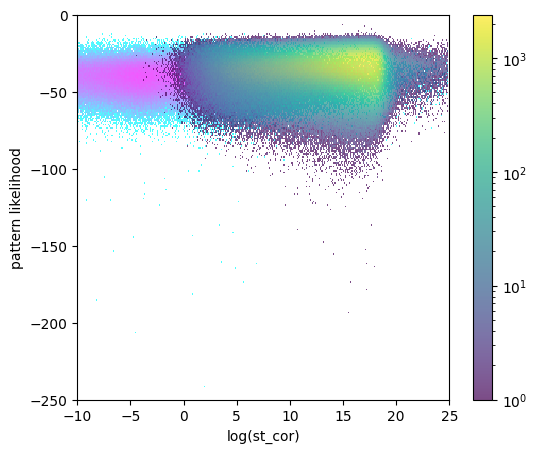

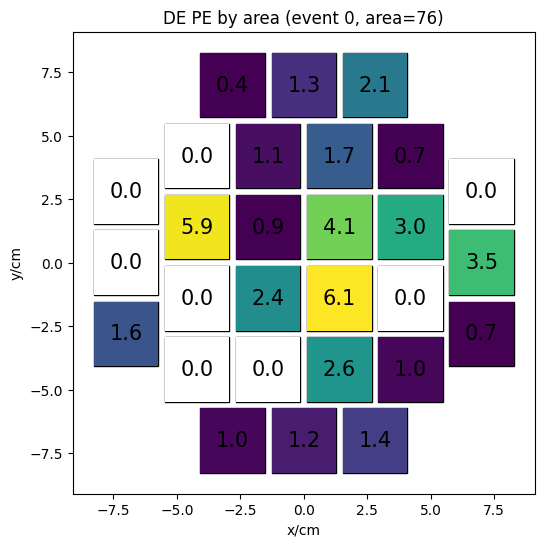

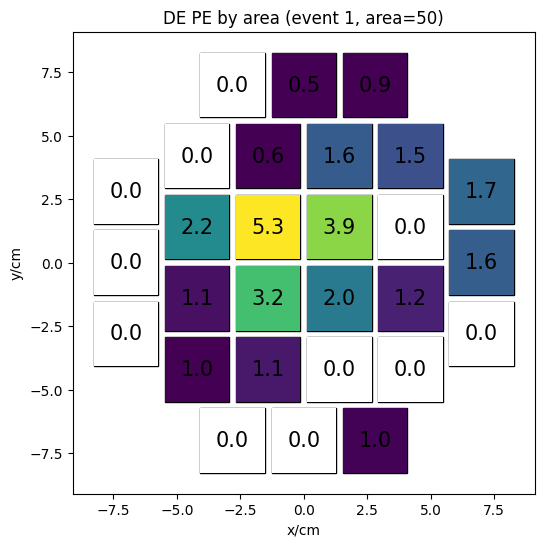

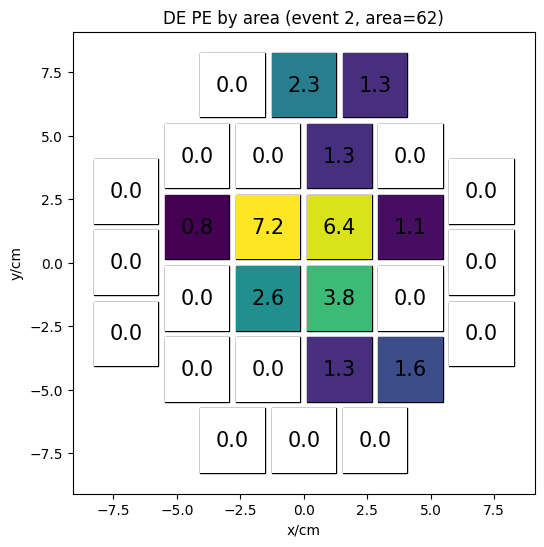

In [8]:
# ============================================================
# 8) 验证图：DE 与 CEvNS 的 log(st_cor) vs pattern likelihood
# ============================================================
from matplotlib.colors import LogNorm

x_bins = np.arange(-10, 25, 0.1)
y_bins = np.arange(-250, 0, 1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.log(cevns_st_cor), cevns_pattern, bins=(x_bins, y_bins),
              cmap='cool', norm=LogNorm(), alpha=0.7)
h = ax.hist2d(np.log(st_cor), pattern, bins=(x_bins, y_bins),
              cmap='viridis', norm=LogNorm(), alpha=0.7)
ax.set_xlabel('log(st_cor)')
ax.set_ylabel('pattern likelihood')
plt.colorbar(h[3], ax=ax)
plt.xlim(-10, 25)
plt.ylim(-250, 0)
plt.show()

# pattern_plot（复用原 notebook 的绘图函数，pmt 布局来自 pipe.pmt_top）
def pattern_plot(phe_pmt, electron=[], pos_recons=[], pmt_info=None, title="", savefig=False):
    import matplotlib as mpl
    import matplotlib.cm as cm
    from matplotlib.patches import Rectangle
    from mpl_toolkits.axes_grid1 import ImageGrid

    if pmt_info is None:
        pmt_info = pipe.pmt_top
    phe_pmt = np.nan_to_num(np.asarray(phe_pmt), nan=0.0)
    max_val = phe_pmt.max()
    norm = (mpl.colors.Normalize(vmin=0, vmax=max(1, max_val)) if max_val <= 1
            else mpl.colors.LogNorm(vmin=1, vmax=max_val, clip=True))
    cmap = mpl.cm.viridis

    fig = plt.figure(figsize=(7, 6))
    grid = ImageGrid(fig, 111, (1, 1))
    for pmt_id in range(28):
        pmt = pmt_info[pmt_id]
        color = 'white' if phe_pmt[pmt_id] < 0.1 else cmap(norm(phe_pmt[pmt_id]))
        grid[0].text(pmt['x'], pmt['y'], str(round(phe_pmt[pmt_id], 1)),
                     ha='center', va='center', fontsize=15)
        grid[0].add_patch(Rectangle(xy=(pmt['x'] - 1.27, pmt['y'] - 1.27), width=2.54,
                                    height=2.54, angle=pmt['rot_z'], rotation_point='center',
                                    fc='none', ec='black', lw=1))
        grid[0].add_patch(Rectangle(xy=(pmt['x'] - 1.27, pmt['y'] - 1.27), width=2.54,
                                    height=2.54, angle=pmt['rot_z'], rotation_point='center',
                                    fc=color, alpha=1))
    grid[0].axis('equal')
    grid[0].set_xlabel('x/cm')
    grid[0].set_ylabel('y/cm')
    grid[0].set_title(title)
    if savefig:
        plt.savefig(title + ".png")
    plt.show()
    return 0

# 示例：DE 前 3 个事件的 PMT 光斑
for i in range(min(3, len(DE_area))):
    pattern_plot(DE_pe_by_area[i], pmt_info=pipe.pmt_top,
                 title=f"DE PE by area (event {i}, area={DE_area[i]:.0f})")


## 9) 后续分析（迁移自 `20260730.ipynb`）

以下 cell 复用前文已生成的 `pipe` / `pipe_cevns` 以及 DE/CEvNS 分析数组，完成与原
`20260730.ipynb` 相同的后续分析：

1. pile-up 多重数速率；
2. PMT 光斑可视化（含真值与重建位置叠加）；
3. `log(st_cor) / area / pattern likelihood` 二维分布；
4. 分类器 score 的 `k_area` 优化、阈值选取与判别图；
5. cut 后的 DE area 谱及年速率估计。

图像和 `analysis_result.npz` / `summary.json` 默认写入
`output/20260730_sampled/`（即抽样合并数组所在目录）。


分析输出目录: /home/leiyang/TPC_DE_SIm-test/output/20260730_sampled
time_range_s = 5000.0
  order=2: 426.868 Hz
  order=3: 74.1702 Hz
  order=4: 19.5882 Hz
  order=5: 6.6556 Hz
  order=6: 2.7274 Hz
  order=7: 1.2658 Hz
order>=3 总速率 = 10.6488 Hz


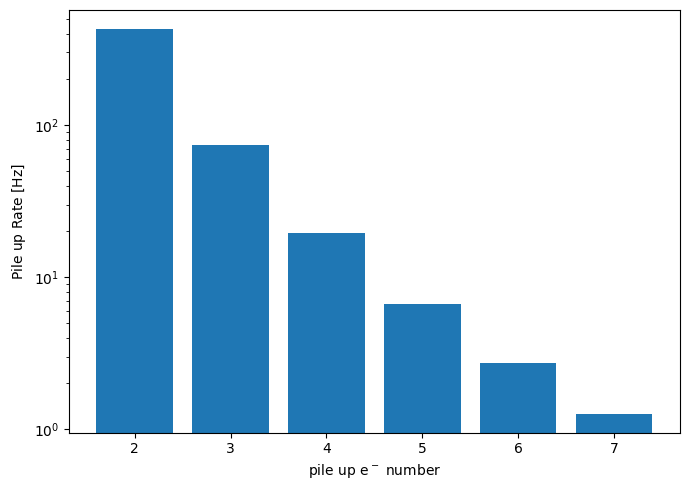

In [9]:
# ============================================================
# 9.1 DE pile-up multiplicity 速率
# ============================================================
ANALYSIS_DIR = MERGED_INPUT.parent
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
print("分析输出目录:", ANALYSIS_DIR)

event_rate = np.array(
    [len(coef) for coef in pipe.pile_up_pattern_coef]
) / pipe.time_range_s

print("time_range_s =", pipe.time_range_s)
for order, rate in zip(pipe.pile_up_orders, event_rate):
    print(f"  order={order}: {rate:.6g} Hz")
print("order>=3 总速率 =", np.sum(event_rate[3:]), "Hz")

fig = plt.figure(figsize=(7, 5))
plt.yscale("log")
plt.bar(pipe.pile_up_orders, event_rate)
plt.ylabel(r"$\mathrm{Pile\ up\ Rate\ [Hz]}$")
plt.xlabel(r"$\mathrm{pile\ up\ e^-\ number}$")
plt.tight_layout()
#plt.savefig(ANALYSIS_DIR / "Pile_up_Rate.png", dpi=150)
plt.show()


## 9.2 PMT 光斑绘图函数

与 `20260730.ipynb` 中 `pattern_plot` 一致的完整版实现，额外支持叠加
`electron`（真值位置）和 `pos_recons`（重建位置）。

In [10]:
# ============================================================
# 9.2 PMT 光斑绘图函数（完整版）
# ============================================================
import matplotlib as mpl
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid


def pattern_plot(phe_pmt, electron=[], pos_recons=[], pmt_info=None,
                 title="", savefig=False):
    """绘制 top PMT array 的 PE 光斑，并可叠加电子真值与重建位置。"""
    if pmt_info is None:
        pmt_info = pipe.pmt_top

    phe_pmt = np.nan_to_num(np.asarray(phe_pmt), nan=0.0)
    max_val = float(np.max(phe_pmt)) if phe_pmt.size else 0.0
    if max_val <= 1:
        norm = mpl.colors.Normalize(vmin=0, vmax=max(1.0, max_val))
    else:
        norm = mpl.colors.LogNorm(vmin=1, vmax=max_val, clip=True)
    cmap = mpl.cm.viridis

    fig = plt.figure(figsize=(7, 6))
    grid = ImageGrid(
        fig, 111, (1, 1),
        cbar_mode="single", cbar_location="right", cbar_pad=0.1,
    )
    artists = []

    n_pmt = min(28, len(pmt_info))
    for pmt_id in range(n_pmt):
        pmt = pmt_info[pmt_id]
        pe_value = float(phe_pmt[pmt_id]) if pmt_id < len(phe_pmt) else 0.0
        pmt_color = "white" if pe_value < 0.1 else cmap(norm(pe_value))

        grid[0].text(
            pmt["x"], pmt["y"], str(round(pe_value, 1)),
            ha="center", va="center", fontsize=15,
        )
        grid[0].add_patch(
            Rectangle(
                xy=(pmt["x"] - 1.27, pmt["y"] - 1.27),
                width=2.54, height=2.54, angle=pmt["rot_z"],
                rotation_point="center", fc="none", ec="black", lw=1,
            )
        )
        patch = Rectangle(
            xy=(pmt["x"] - 1.27, pmt["y"] - 1.27),
            width=2.54, height=2.54, angle=pmt["rot_z"],
            rotation_point="center", fc=pmt_color, alpha=1,
        )
        grid[0].add_patch(patch)
        artists.append(patch)

    if len(electron) > 0:
        try:
            grid[0].plot(
                electron["xd"] / 10, electron["yd"] / 10,
                "ro", markersize=12, label="True position",
            )
        except Exception as exc:
            print("electron overlay failed:", exc)

    if len(pos_recons) > 0:
        try:
            grid[0].plot(
                pos_recons[0] / 10, pos_recons[1] / 10,
                "b*", markersize=12, label="Recon position",
            )
        except Exception as exc:
            print("pos_recons overlay failed:", exc)

    grid[0].axis("equal")
    grid[0].set_xlabel("x/cm")
    grid[0].set_ylabel("y/cm")
    grid[0].set_title(title)
    if len(electron) > 0 or len(pos_recons) > 0:
        grid[0].legend(loc="upper right", fontsize=8)

    if phe_pmt.size:
        grid.cbar_axes[0].colorbar(
            mpl.cm.ScalarMappable(norm=norm, cmap=cmap), label="PE",
        )

    if savefig:
        fname = MERGED_INPUT.parent / f"{title}.png"
        plt.savefig(fname, dpi=150)
        print("saved:", fname)
    plt.show()
    return 0


## 9.3 DE 与 CEvNS 的二维分布

分别比较 space-time correlation、pattern likelihood 与 area。

/tmp/ipykernel_2200553/2793814668.py:14: RuntimeWarning: divide by zero encountered in log
  np.log(cevns_st_cor[cevns_area_mask]), cevns_pattern[cevns_area_mask],


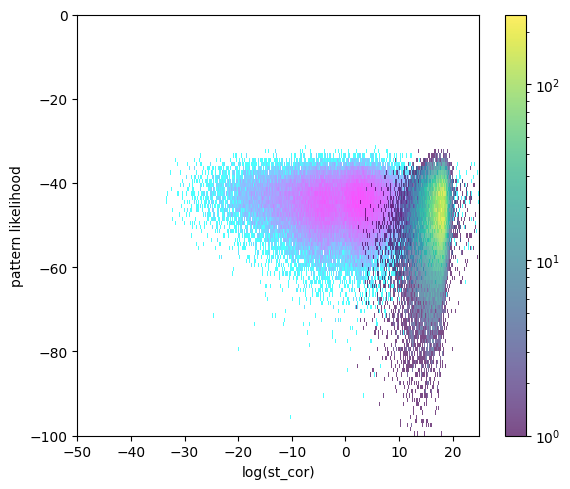

/tmp/ipykernel_2200553/2793814668.py:33: RuntimeWarning: divide by zero encountered in log
  np.log(cevns_st_cor), cevns_area,


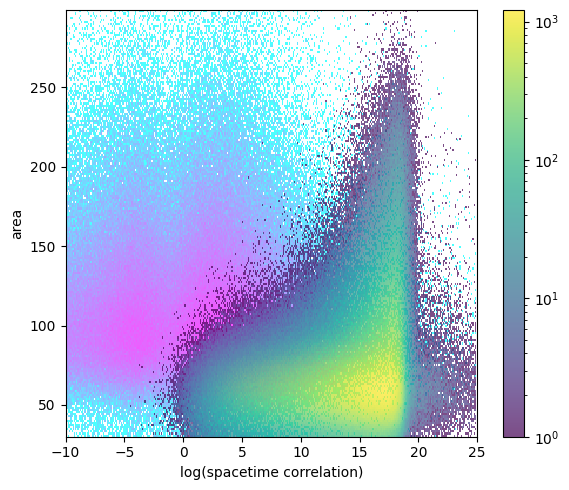

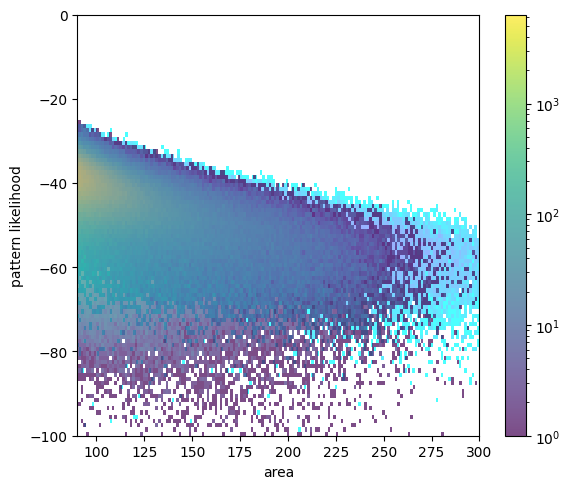

In [37]:
# ============================================================
# 9.3 log(st_cor) / area / pattern likelihood 二维分布
# ============================================================
from matplotlib.colors import LogNorm
cevns_area_mask = (cevns_area > 120) & (cevns_area < 160)
DE_area_mask = (DE_area > 120) & (DE_area < 160)

x_bins = np.arange(-50, 25, 0.1)
y_bins = np.arange(-100, 0, 1)

# ---- log(st_cor) vs pattern likelihood ----
fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(
    np.log(cevns_st_cor[cevns_area_mask]), cevns_pattern[cevns_area_mask],
    bins=(x_bins, y_bins), cmap="cool", norm=LogNorm(), alpha=0.7,
)
h = ax.hist2d(
    np.log(st_cor[DE_area_mask]), pattern[DE_area_mask],
    bins=(x_bins, y_bins), cmap="viridis", norm=LogNorm(), alpha=0.7,
)
ax.set_xlabel("log(st_cor)")
ax.set_ylabel("pattern likelihood")
plt.colorbar(h[3], ax=ax)
plt.xlim(-50, 25)
plt.ylim(-100, 0)
plt.tight_layout()
#plt.savefig(ANALYSIS_DIR / "st_cor_vs_pattern.png", dpi=150)
plt.show()

# ---- log(st_cor) vs area ----
fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(
    np.log(cevns_st_cor), cevns_area,
    bins=(x_bins, 200), cmap="cool", norm=LogNorm(), alpha=0.7,
)
h = ax.hist2d(
    np.log(st_cor), DE_area,
    bins=(x_bins, 200), cmap="viridis", norm=LogNorm(), alpha=0.7,
)
ax.set_xlabel("log(spacetime correlation)")
ax.set_ylabel("area")
plt.colorbar(h[3], ax=ax)
plt.xlim(-10, 25)
plt.tight_layout()
#plt.savefig(ANALYSIS_DIR / "st_cor_vs_area.png", dpi=150)
plt.show()

# ---- area vs pattern likelihood ----
fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(
    cevns_area, cevns_pattern,
    bins=(200, y_bins), cmap="cool", norm=LogNorm(), alpha=0.7,
)
h = ax.hist2d(
    DE_area, pattern,
    bins=(200, y_bins), cmap="viridis", norm=LogNorm(), alpha=0.7,
)
ax.set_xlabel("area")
ax.set_ylabel("pattern likelihood")
plt.colorbar(h[3], ax=ax)
plt.xlim(90, 300)
plt.ylim(-100, 0)
plt.tight_layout()
#plt.savefig(ANALYSIS_DIR / "area_vs_pattern.png", dpi=150)
plt.show()


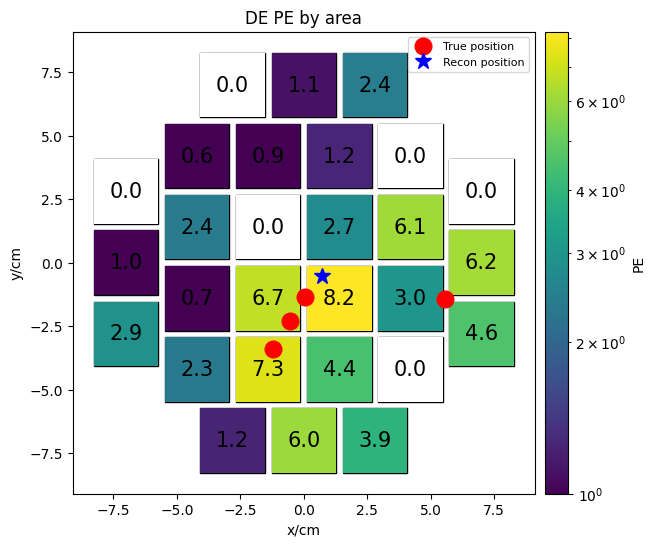

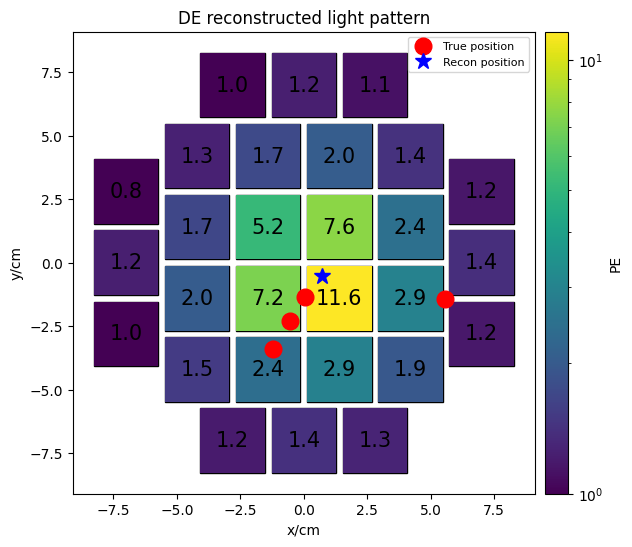

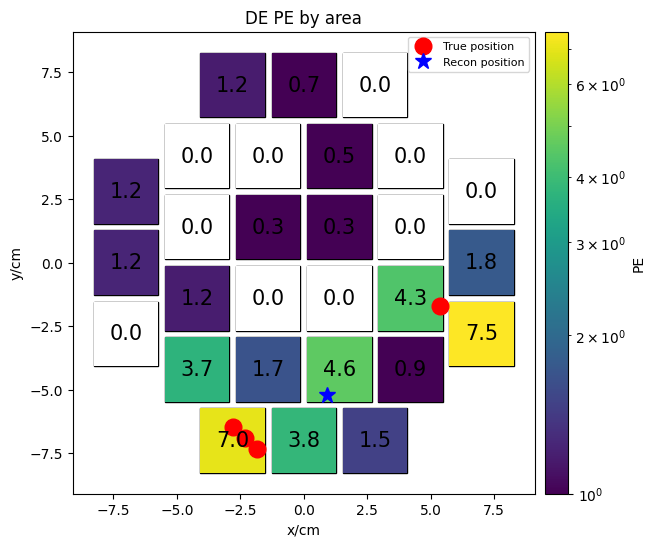

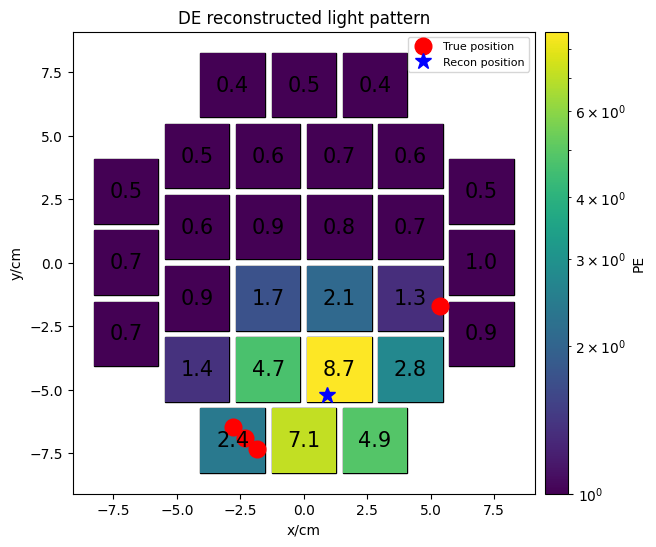

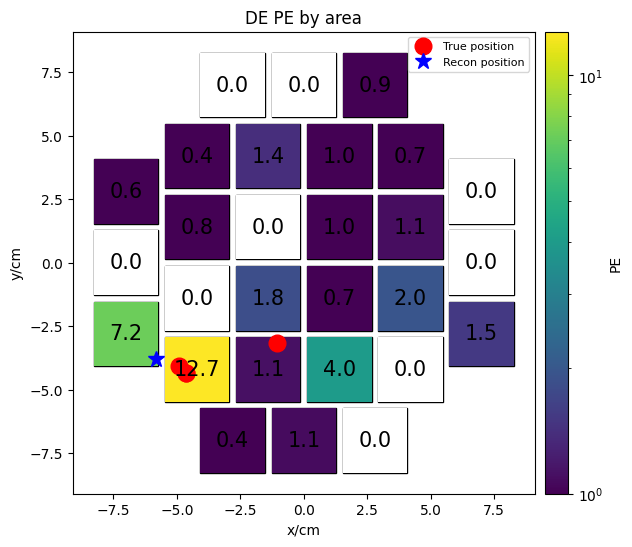

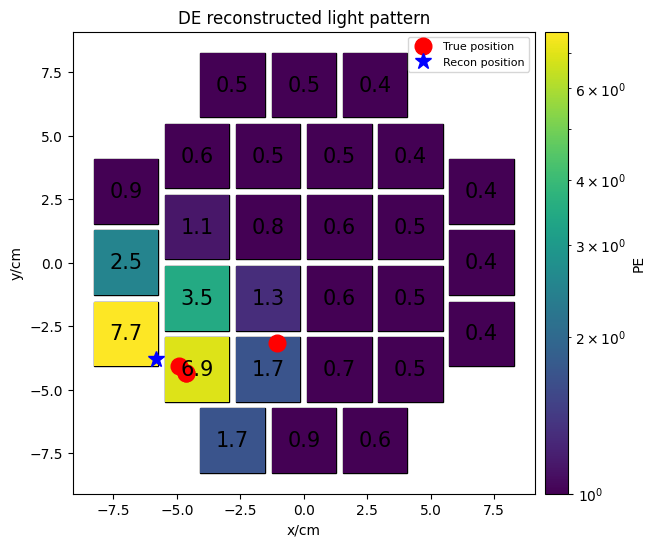

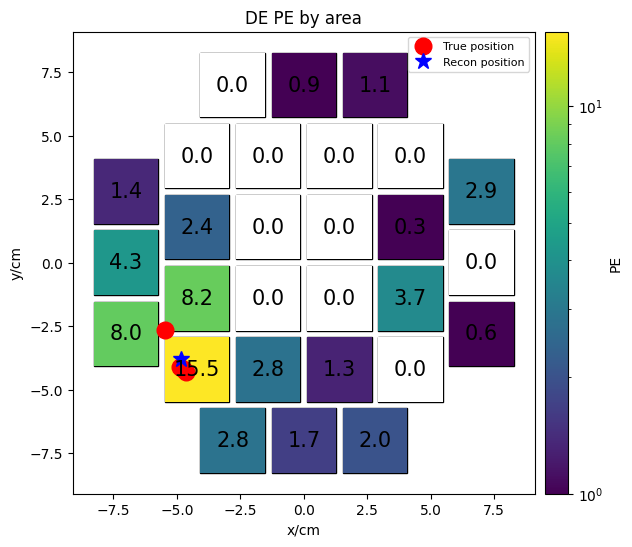

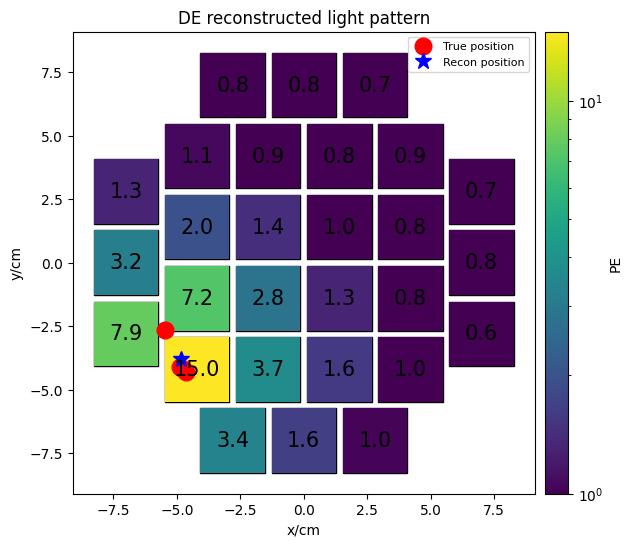

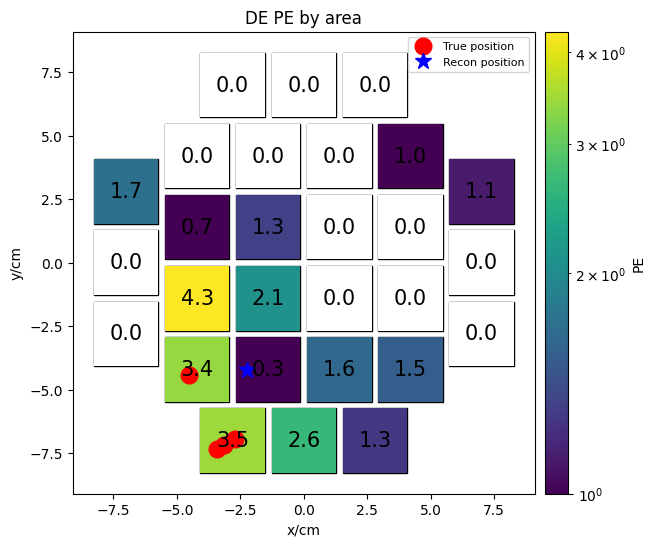

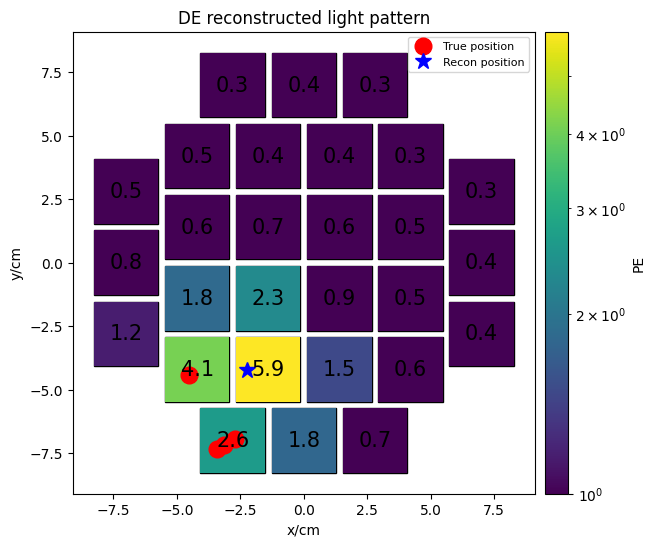

In [12]:
e_num = 4
mask = np.ptp(pipe.pile_up_events[e_num-2]['eventId'], axis=1) != 0 
np.sum(mask)
valid_indices = np.where(mask)[0]

for i in range(min(5, len(valid_indices))):
    idx = valid_indices[i]
    pattern_plot(pipe.pile_up_results[e_num-2].pe_by_area[idx], 
                 electron=pipe.pile_up_events[e_num-2][idx], 
                 pos_recons = pipe.pile_up_pos_recon[e_num-2][idx], 
                 pmt_info = pipe.pmt_top,title = "DE PE by area")
    pattern_plot(pipe.pile_up_recons_light_pattern[e_num-2][idx], 
                 electron=pipe.pile_up_events[e_num-2][idx], 
                 pos_recons = pipe.pile_up_pos_recon[e_num-2][idx], 
                 pmt_info = pipe.pmt_top,title = "DE reconstructed light pattern")

CEvNS pattern > -50 的事件数: 639165


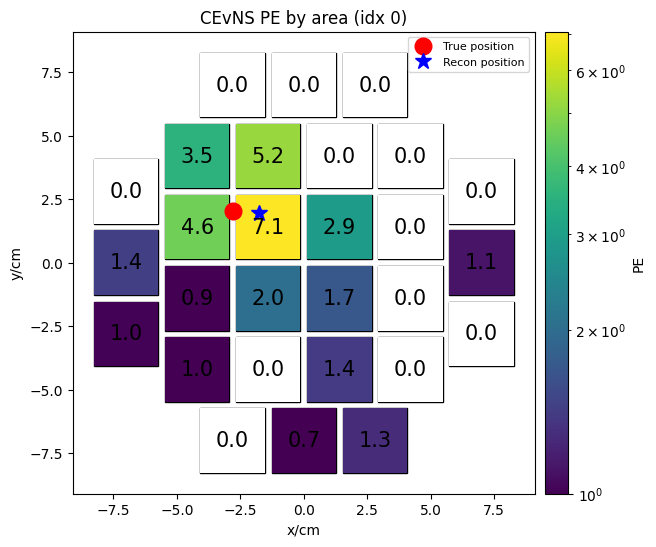

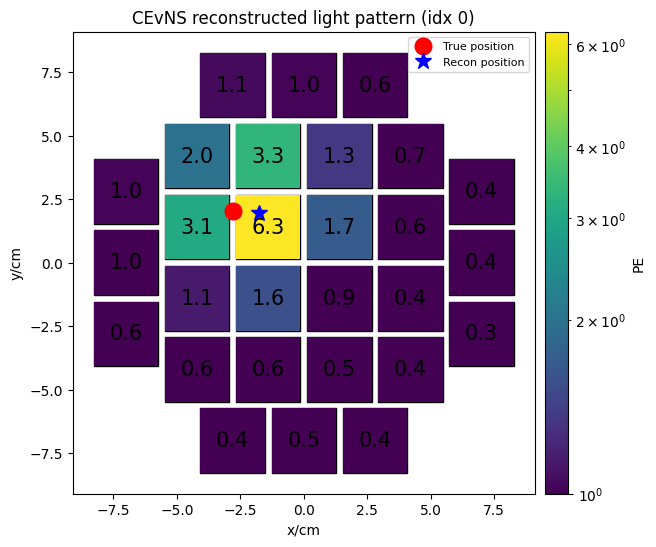

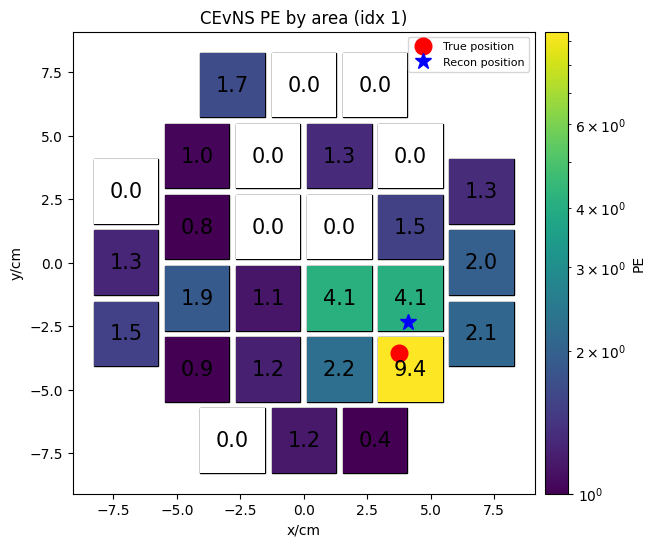

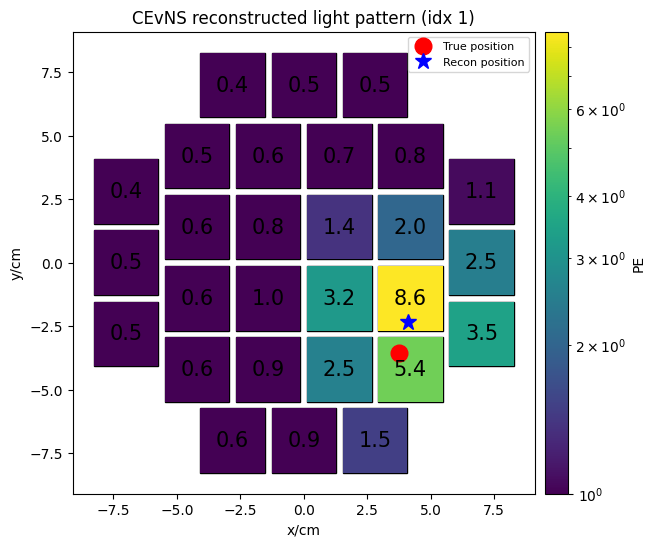

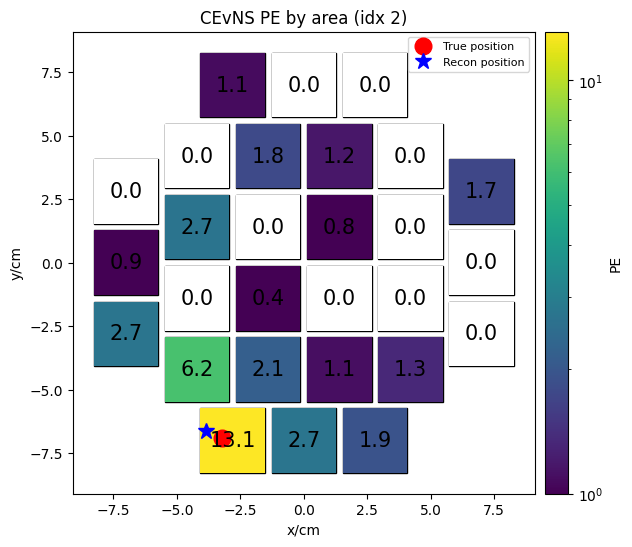

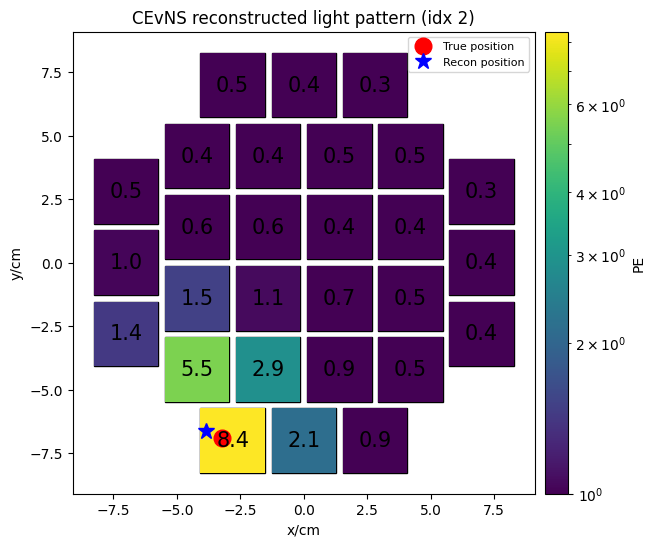

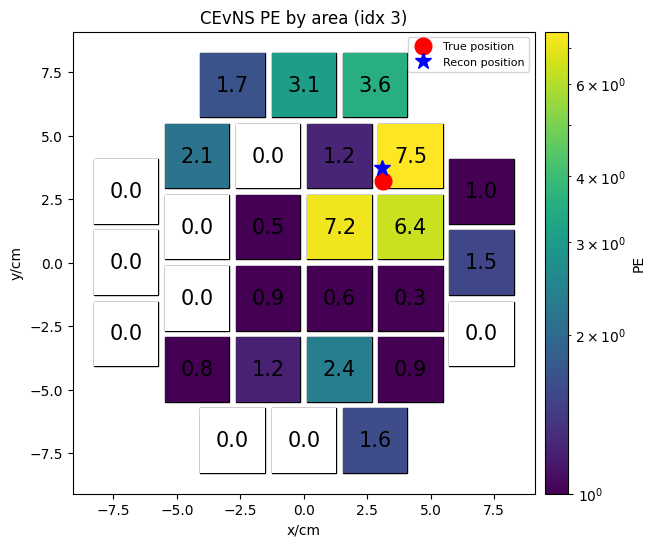

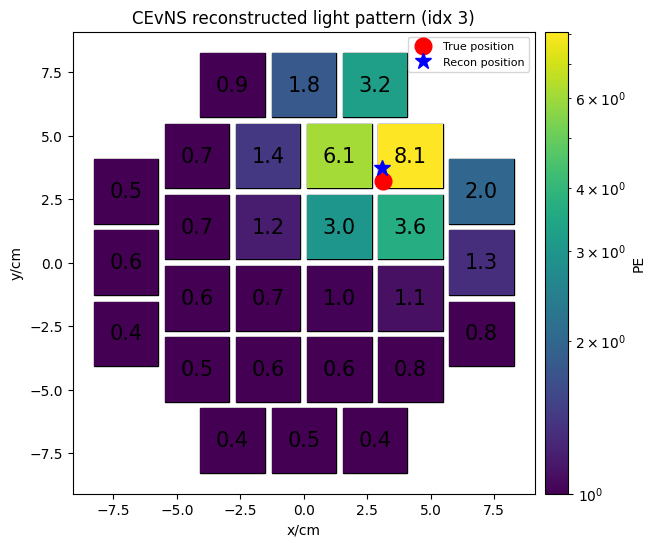

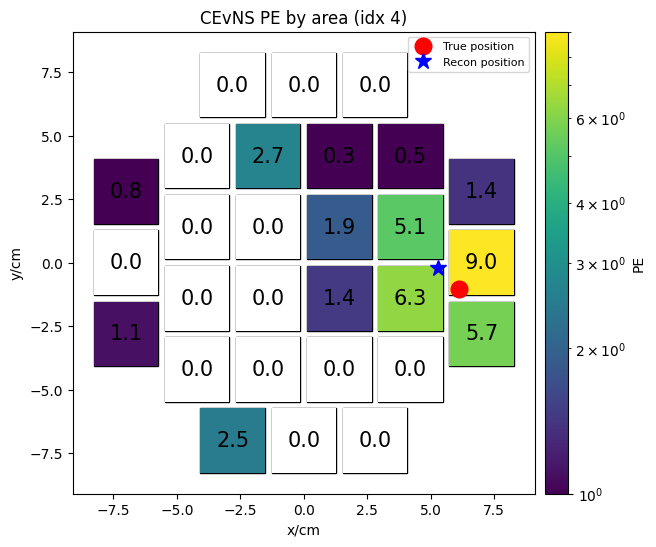

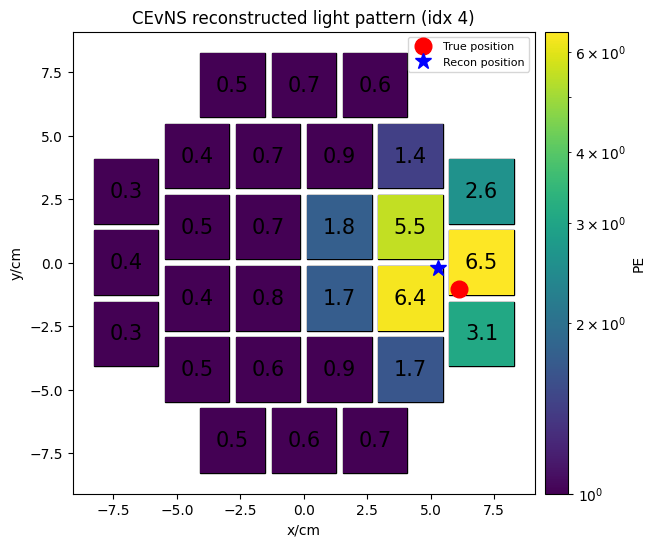

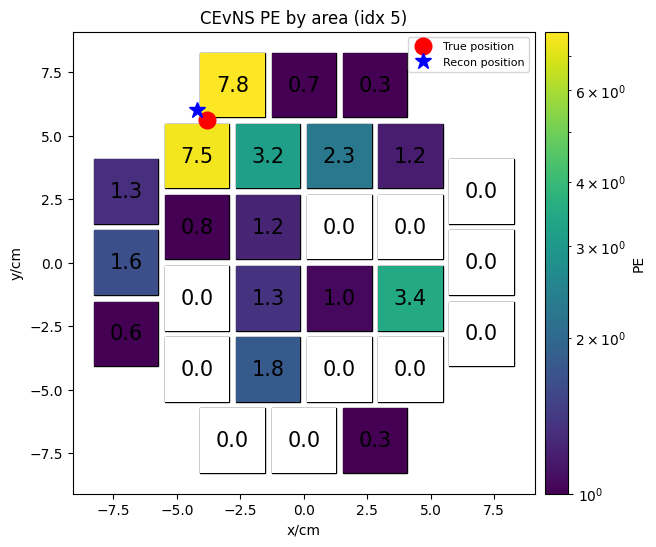

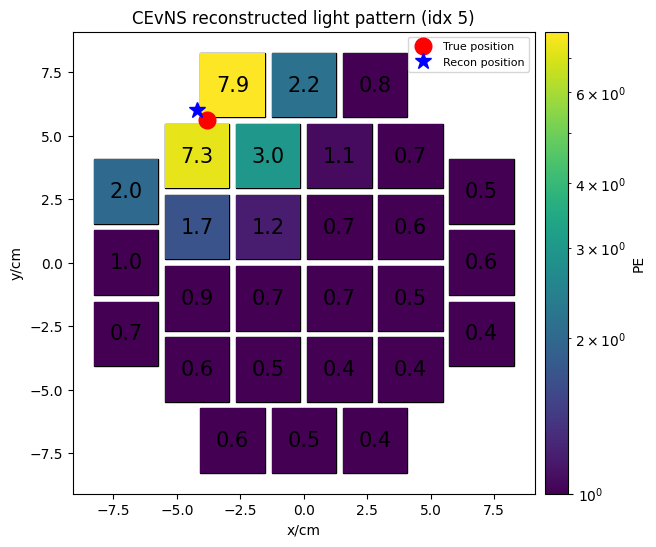

In [13]:
# ============================================================
# 9.4 CEvNS 高 pattern likelihood 光斑示例
# ============================================================
mask = cevns_pattern > -50
valid_indices = np.where(mask)[0]
print("CEvNS pattern > -50 的事件数:", len(valid_indices))

for i in range(min(6, len(valid_indices))):
    idx = valid_indices[i]
    pattern_plot(
        cevns_pe_by_area[idx],
        electron=arr["pos_original"][idx],
        pos_recons=arr["pos_recon"][idx],
        pmt_info=pipe.pmt_top,
        title=f"CEvNS PE by area (idx {idx})",
    )
    pattern_plot(
        cevns_recon_light_pattern[idx],
        electron=arr["pos_original"][idx],
        pos_recons=arr["pos_recon"][idx],
        pmt_info=pipe.pmt_top,
        title=f"CEvNS reconstructed light pattern (idx {idx})",
    )


## 9.5 Score 判别与 cut 优化

构造 `k_area * area - log(st_cor)`，在 DE 泄漏率为 0.001 的约束下扫描
`k_area`，选择 CEvNS 保留比例（exposure）最大的参数。

ROI 内事件数: DE = 119490 , CEvNS = 244116


scan k_area:   0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_2200553/214827413.py:5: RuntimeWarning: divide by zero encountered in log
  return k_area * area - np.log(st_cor)
scan k_area: 100%|██████████| 100/100 [00:01<00:00, 81.64it/s]


最优参数: k_area=0.0550, score threshold=5.2790, CEvNS exposure=0.761974


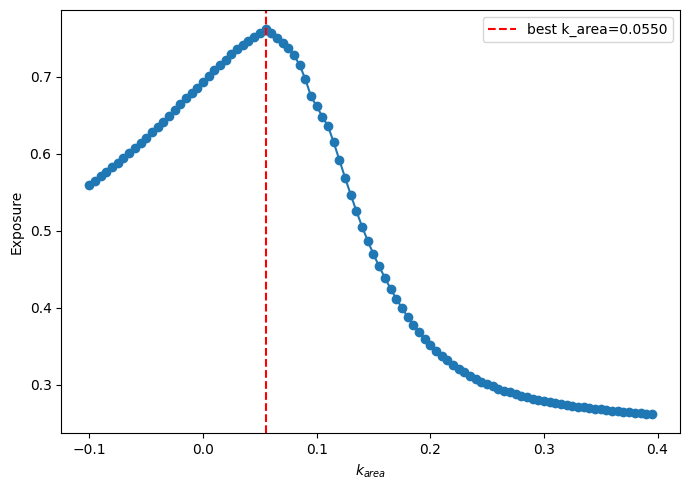

In [14]:
# ============================================================
# 9.5 分类器 score：扫描 k_area，最大化 CEvNS exposure
# ============================================================
def calculate_score(st_cor, area, k_area):
    return k_area * area - np.log(st_cor)


cevns_ROI_mask = (cevns_area > 120) & (cevns_area < 300)
DE_ROI_mask = (DE_area > 120) & (DE_area < 300)
print("ROI 内事件数: DE =", int(np.sum(DE_ROI_mask)),
      ", CEvNS =", int(np.sum(cevns_ROI_mask)))

from tqdm import tqdm

k_area_list = np.arange(-0.1, 0.4, 0.005)
k_list = []
exposure_k = []

for k in tqdm(k_area_list, desc="scan k_area"):
    score_cevns = calculate_score(
        cevns_st_cor[cevns_ROI_mask], cevns_area[cevns_ROI_mask], k_area=k
    )
    score_DE = calculate_score(
        st_cor[DE_ROI_mask], DE_area[DE_ROI_mask], k_area=k
    )
    valid_score_cevns = score_cevns[~np.isnan(score_cevns)]
    valid_score_DE = score_DE[~np.isnan(score_DE)]

    if len(valid_score_DE) == 0 or len(valid_score_cevns) == 0:
        exposure_k.append(np.nan)
        k_list.append([float(k), np.nan])
        continue

    score_thr = np.percentile(valid_score_DE, 100 - 0.001)
    exposure_k.append(np.mean(valid_score_cevns > score_thr))
    k_list.append([float(k), float(score_thr)])

exposure_k = np.array(exposure_k)
k_list = np.array(k_list)

index_of_max = int(np.nanargmax(exposure_k))
best_k_area = float(k_list[index_of_max, 0])
best_score_thr = float(k_list[index_of_max, 1])
best_exposure = float(exposure_k[index_of_max])
print(f"最优参数: k_area={best_k_area:.4f}, score threshold={best_score_thr:.4f}, "
      f"CEvNS exposure={best_exposure:.6f}")

plt.figure(figsize=(7, 5))
plt.plot(k_area_list, exposure_k, marker="o")
plt.axvline(best_k_area, color="red", linestyle="--", label=f"best k_area={best_k_area:.4f}")
plt.xlabel(r"$k_{area}$")
plt.ylabel("Exposure")
plt.legend()
plt.tight_layout()
#plt.savefig(ANALYSIS_DIR / "exposure_vs_k_area.png", dpi=150)
plt.show()

# 后续 cell 使用该最优参数
k_area = best_k_area


/tmp/ipykernel_2200553/1653043777.py:7: RuntimeWarning: divide by zero encountered in log
  ax.hist(np.log(cevns_st_cor), bins=x_bins, alpha=0.7, label="CEvNS")


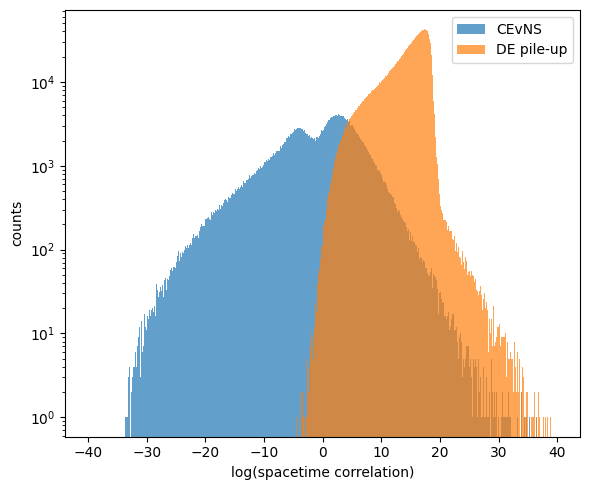

In [30]:
# ============================================================
# 9.6 log(st_cor) 一维分布比较
# ============================================================
x_bins = np.arange(-40, 40, 0.1)

fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(np.log(cevns_st_cor), bins=x_bins, alpha=0.7, label="CEvNS")
ax.hist(np.log(st_cor), bins=x_bins, alpha=0.7, label="DE pile-up")
ax.set_xlabel("log(spacetime correlation)")
ax.set_ylabel("counts")
ax.set_yscale("log")

ax.legend()
plt.tight_layout()
#plt.savefig(ANALYSIS_DIR / "st_cor_1d.png", dpi=150)
plt.show()


## 9.7 阈值选取与分类器 score 判别图

在固定 `k_area` 下扫描 score 阈值；左侧为 DE 泄漏率，右侧为 CEvNS 保留率。

/tmp/ipykernel_2200553/214827413.py:5: RuntimeWarning: divide by zero encountered in log
  return k_area * area - np.log(st_cor)


sel_thres = 5.4000 (index=152)
  DE 泄漏率 = 0.999992
  CEvNS 保留率 = 0.756272


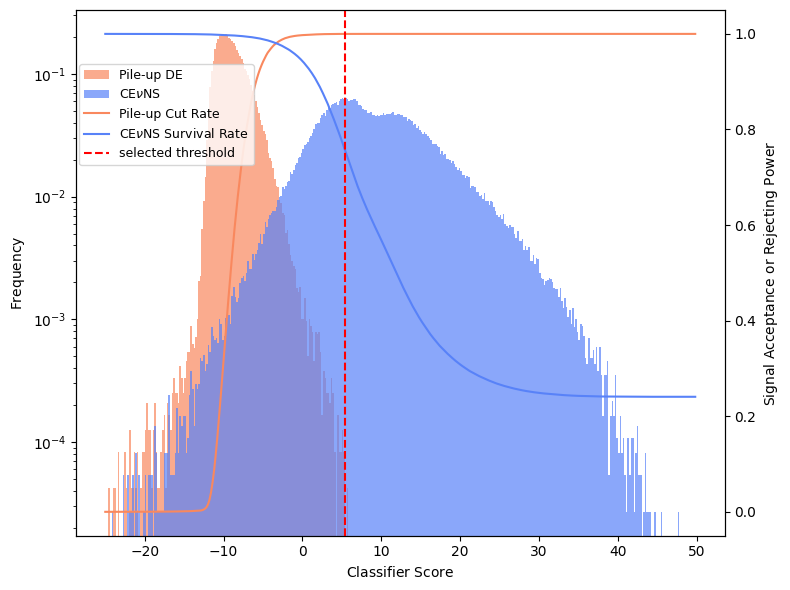

In [16]:
# ============================================================
# 9.7 阈值扫描与分类器判别图
# ============================================================
score_DE = calculate_score(st_cor[DE_ROI_mask], DE_area[DE_ROI_mask], k_area)
score_CEvNS = calculate_score(
    cevns_st_cor[cevns_ROI_mask], cevns_area[cevns_ROI_mask], k_area
)
score_CEvNS = score_CEvNS[~np.isnan(score_CEvNS)]
score_DE = score_DE[~np.isnan(score_DE)]

thresholds = np.arange(-25, 50, 0.2)
left_DE_ratios = []
right_cevns_ratios = []

for threshold in thresholds:
    left_DE_ratios.append(np.sum(score_DE < threshold) / len(score_DE))
    right_cevns_ratios.append(np.sum(score_CEvNS > threshold) / len(score_CEvNS))

left_DE_ratios = np.array(left_DE_ratios)
right_cevns_ratios = np.array(right_cevns_ratios)

# 选取 DE 泄漏率首次低于 1e-5 的阈值（与原 notebook 逻辑一致）
index = int(np.argmax(left_DE_ratios > 1 - 0.00001))
sel_thres = float(thresholds[index])
print(f"sel_thres = {sel_thres:.4f} (index={index})")
print(f"  DE 泄漏率 = {left_DE_ratios[index]:.6g}")
print(f"  CEvNS 保留率 = {right_cevns_ratios[index]:.6g}")

cevns_color = "#5882F8"
DE_color = "#F9885E"

fig, ax1 = plt.subplots(figsize=(8, 6))
bins = np.arange(-25, 50, 0.2)
ax1.hist(score_DE, bins=bins, log=True, label="Pile-up DE",
         alpha=0.7, color=DE_color, density=True)
ax1.hist(score_CEvNS, bins=bins, log=True, label=r"CE$\nu$NS",
         alpha=0.7, color=cevns_color, density=True)
ax1.set_xlabel(r"$\mathrm{Classifier\ Score}$")
ax1.set_ylabel(r"$\mathrm{Frequency}$")

ax2 = ax1.twinx()
ax2.set_ylabel(r"$\mathrm{Signal\ Acceptance\ or\ Rejecting\ Power}$")
ax2.plot(thresholds, left_DE_ratios, label="Pile-up Cut Rate", color=DE_color)
ax2.plot(thresholds, right_cevns_ratios, label=r"CE$\nu$NS Survival Rate",
         color=cevns_color)
ax2.axvline(sel_thres, color="red", linestyle="dashed", label="selected threshold")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines + lines2, labels + labels2, loc=(0.10, 0.72), fontsize=9)
plt.tight_layout()
#plt.savefig(ANALYSIS_DIR / "classifier_score.png", dpi=150)
plt.show()


## 9.8 cut 后 DE area 谱与年速率估计

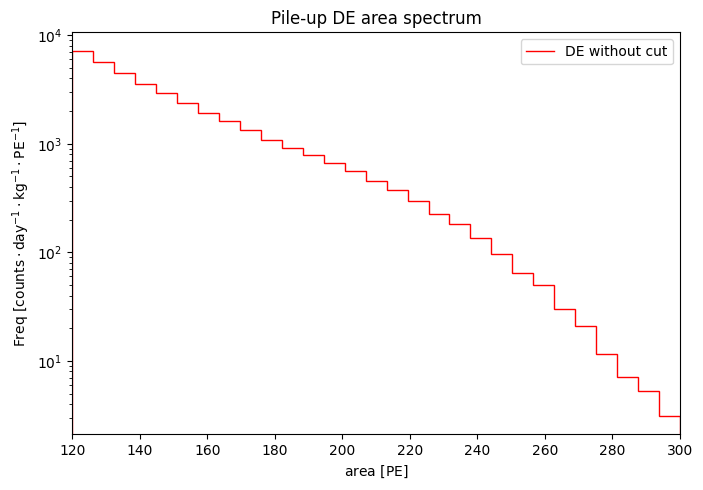

DE ROI 内事件数: 119490, 速率 = 23.898 Hz
cut 后事件数: 1, 速率 = 0.0002 Hz
cut 后年速率 = 6307.2 events/year


In [43]:
# ============================================================
# 9.8 cut 后 DE area 谱与年速率估计
# ============================================================
import json


def plot_area_spectrum(area, total_time, LXe_mass, bins, **kwargs):
    count, bins = np.histogram(area, bins=bins)
    bin_width = np.diff(bins)
    freq = 86400 * count / (bin_width) / total_time / LXe_mass
    ax = plt.gca()
    ax.stairs(freq, edges=bins, **kwargs)
    ax.set_xlabel(r'$\mathrm{area\ [PE]}$')
    ax.set_ylabel(r'$\mathrm{Freq\ [counts \cdot day^{-1} \cdot kg^{-1} \cdot PE^{-1}]}$')
    return ax, count, bins


DE_cut = score_DE > sel_thres
total_time = pipe.time_range_s
bins = np.linspace(120, 300, 30)

plt.figure(figsize=(7, 5))
plot_area_spectrum(
    DE_area[DE_ROI_mask], total_time, LXe_mass=8.98, bins=bins,
    label="DE without cut", color="red",
)
# plot_area_spectrum(
#     DE_area[DE_ROI_mask][DE_cut], total_time, LXe_mass=8.98, bins=bins,
#     label="DE with cut", color="blue",
# )
plt.yscale("log")
plt.legend()
plt.title("Pile-up DE area spectrum")
plt.tight_layout()
plt.xlim(120, 300)
#plt.savefig(ANALYSIS_DIR / "DE_area_spectrum.png", dpi=150)
plt.show()

n_de_roi = int(np.sum(DE_ROI_mask))
n_de_after_cut = int(np.sum(DE_cut))
rate_de_roi = n_de_roi / total_time
rate_de_after_cut = n_de_after_cut / total_time
rate_de_per_year = rate_de_after_cut * 3600 * 24 * 365

print(f"DE ROI 内事件数: {n_de_roi}, 速率 = {rate_de_roi:.6g} Hz")
print(f"cut 后事件数: {n_de_after_cut}, 速率 = {rate_de_after_cut:.6g} Hz")
print(f"cut 后年速率 = {rate_de_per_year:.6g} events/year")

# # 保存可复用的分析结果
# np.savez(
#     ANALYSIS_DIR / "analysis_result.npz",
#     de_st_cor=st_cor,
#     de_pattern=pattern,
#     de_area=DE_area,
#     cevns_st_cor=cevns_st_cor,
#     cevns_pattern=cevns_pattern,
#     cevns_area=cevns_area,
#     k_area_list=k_area_list,
#     exposure_k=exposure_k,
#     best_k_area=best_k_area,
#     best_score_thr=best_score_thr,
#     sel_thres=sel_thres,
#     thresholds=thresholds,
#     left_DE_ratios=left_DE_ratios,
#     right_cevns_ratios=right_cevns_ratios,
#     score_DE=score_DE,
#     score_CEvNS=score_CEvNS,
#     DE_ROI_mask=DE_ROI_mask,
#     cevns_ROI_mask=cevns_ROI_mask,
#     DE_cut=DE_cut,
# )

# summary = {
#     "time_range_s": float(total_time),
#     "n_de_roi": int(n_de_roi),
#     "n_de_after_cut": int(n_de_after_cut),
#     "rate_de_roi_hz": float(rate_de_roi),
#     "rate_de_after_cut_hz": float(rate_de_after_cut),
#     "rate_de_per_year": float(rate_de_per_year),
#     "best_k_area": float(best_k_area),
#     "best_score_thr": float(best_score_thr),
#     "best_exposure": float(best_exposure),
#     "sel_thres": float(sel_thres),
# }
# with open(ANALYSIS_DIR / "summary.json", "w", encoding="utf-8") as f:
#     json.dump(summary, f, ensure_ascii=False, indent=2)
# print("已保存 analysis_result.npz 与 summary.json 到", ANALYSIS_DIR)


## 10) `recon_pattern` 与 `light_pattern` 对比分析

这里沿用当前 kernel 中已经生成的变量：

- `light_pattern`：按真实电子位置生成、经面积窗口筛选后的期望光斑；
- `recons_light_pattern`：按重建位置重新生成的期望光斑；
- `pe_by_area`：按各通道面积折合成的观测 PE。

对比内容包括：事件总光量、逐通道一致性、Poisson pattern likelihood，以及典型事件光斑。


In [18]:
# ============================================================
# 10.1 组装并检查 light_pattern / recon_light_pattern
# ============================================================
from matplotlib.colors import LogNorm

# DE 侧：每个 pile-up multiplicity 各有一个 light_pattern 和 recons_light_pattern
DE_light_pattern = np.concatenate(
    [r.light_pattern for r in pipe.pile_up_results], axis=0
)
DE_recon_light_pattern = np.concatenate(
    pipe.pile_up_recons_light_pattern, axis=0
)

# CEvNS 侧
cevns_light_pattern = arr["light_pattern"]
cevns_recon_light_pattern = arr["recons_light_pattern"]

print("DE_pe_by_area          :", DE_pe_by_area.shape)
print("DE_light_pattern       :", DE_light_pattern.shape)
print("DE_recon_light_pattern :", DE_recon_light_pattern.shape)
print()
print("cevns_pe_by_area          :", cevns_pe_by_area.shape)
print("cevns_light_pattern       :", cevns_light_pattern.shape)
print("cevns_recon_light_pattern :", cevns_recon_light_pattern.shape)

assert DE_light_pattern.shape == DE_pe_by_area.shape
assert DE_recon_light_pattern.shape == DE_pe_by_area.shape
assert cevns_light_pattern.shape == cevns_pe_by_area.shape
assert cevns_recon_light_pattern.shape == cevns_pe_by_area.shape
print("shape 检查通过")


DE_pe_by_area          : (2656375, 56)
DE_light_pattern       : (2656375, 56)
DE_recon_light_pattern : (2656375, 56)

cevns_pe_by_area          : (733098, 56)
cevns_light_pattern       : (733098, 56)
cevns_recon_light_pattern : (733098, 56)
shape 检查通过


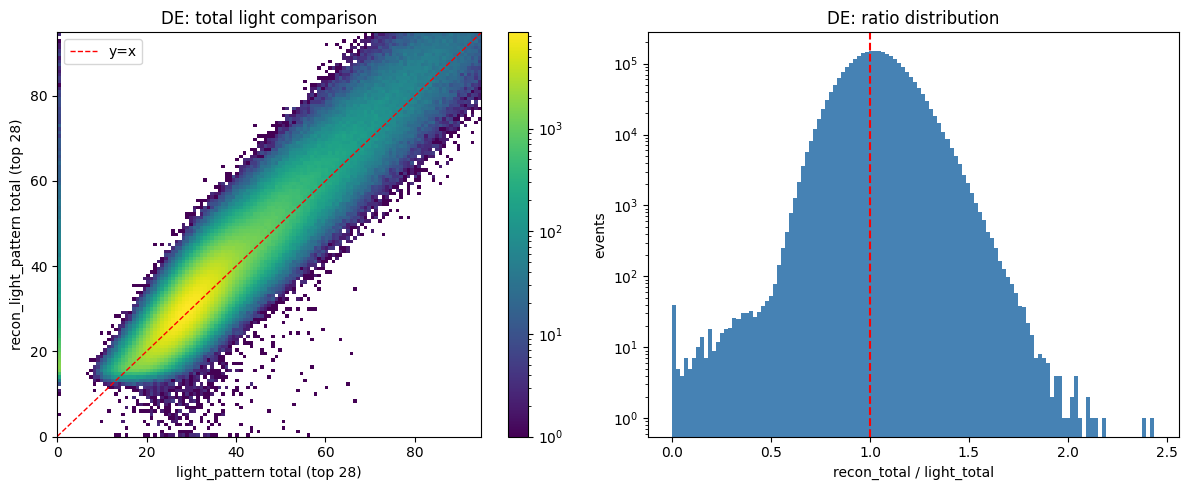

DE: median ratio = 1.031, mean ratio = 1.035


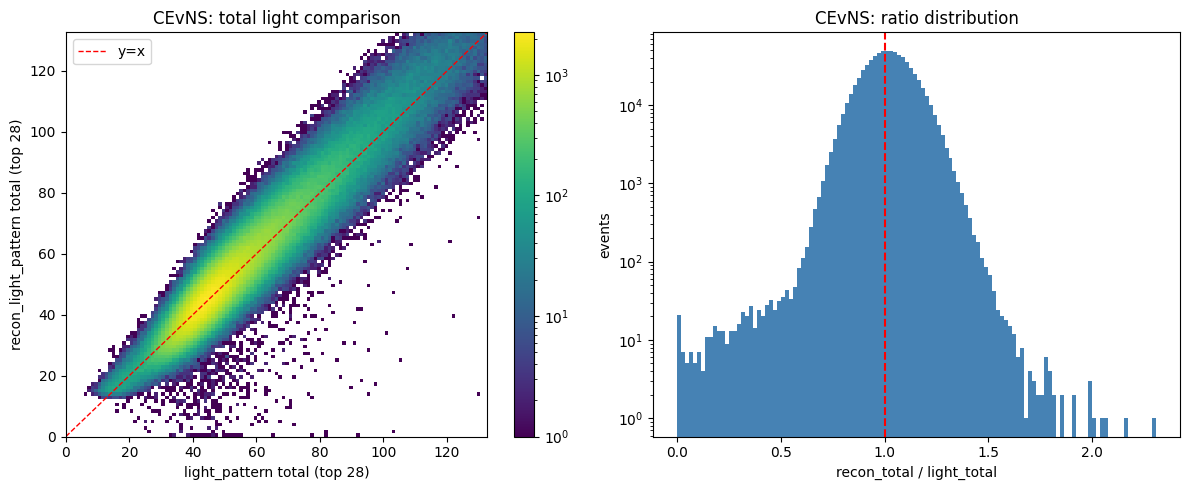

CEvNS: median ratio = 1.016, mean ratio = 1.018


In [19]:
# ============================================================
# 10.2 事件总光量：light_pattern vs recon_light_pattern
# ============================================================
N_TOP = 28
N_PMT = 56

def top_total(pattern):
    """每个事件在前 N_TOP 个 top-PMT 通道的总期望光量。"""
    return np.nansum(pattern[:, :N_TOP], axis=1)


datasets = [
    ("DE", DE_light_pattern, DE_recon_light_pattern),
    ("CEvNS", cevns_light_pattern, cevns_recon_light_pattern),
]

for name, light, recon in datasets:
    true_tot = top_total(light)
    recon_tot = top_total(recon)
    valid = true_tot > 0

    xmax = np.percentile(true_tot, 99.5)
    ymax = np.percentile(recon_tot, 99.5)
    xy_max = max(xmax, ymax)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    h = ax.hist2d(
        true_tot,
        recon_tot,
        bins=(np.linspace(0, xy_max, 120), np.linspace(0, xy_max, 120)),
        cmap="viridis",
        norm=LogNorm(),
    )
    ax.plot([0, xy_max], [0, xy_max], "r--", lw=1, label="y=x")
    ax.set_xlabel("light_pattern total (top 28)")
    ax.set_ylabel("recon_light_pattern total (top 28)")
    ax.set_title(f"{name}: total light comparison")
    ax.legend()
    plt.colorbar(h[3], ax=ax)

    ratio = recon_tot[valid] / true_tot[valid]
    ax = axes[1]
    ax.hist(np.clip(ratio, 0, 3), bins=120, color="steelblue")
    ax.axvline(1, color="red", linestyle="--")
    ax.set_xlabel("recon_total / light_total")
    ax.set_ylabel("events")
    ax.set_title(f"{name}: ratio distribution")
    ax.set_yscale("log")

    plt.tight_layout()
    #plt.savefig(ANALYSIS_DIR / f"{name}_total_light_comparison.png", dpi=150)
    plt.show()

    print(
        f"{name}: median ratio = {np.nanmedian(ratio):.3f}, "
        f"mean ratio = {np.nanmean(ratio):.3f}"
    )


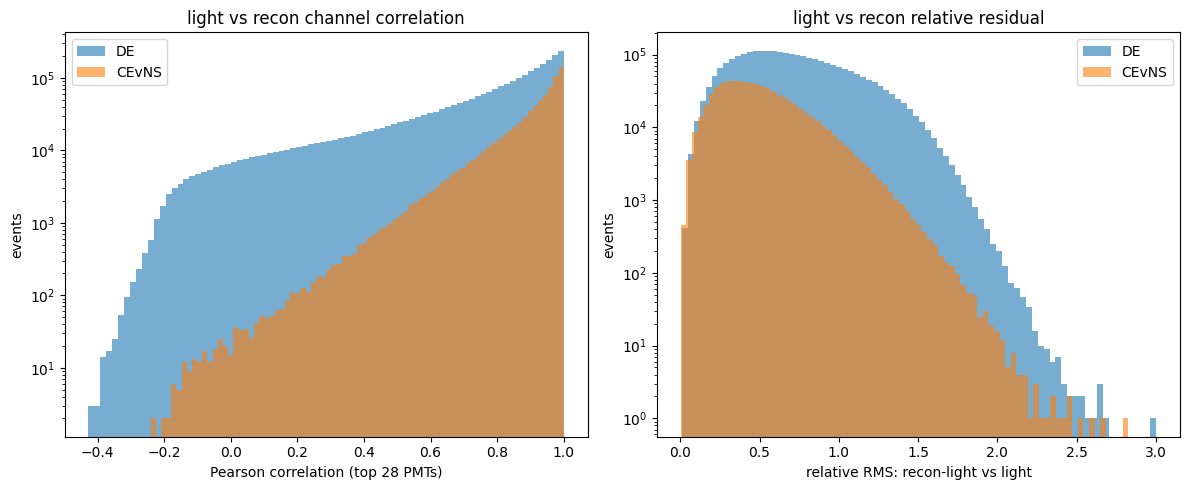

DE   : median corr = 0.8432, median rel RMS = 0.6810
CEvNS: median corr = 0.9415, median rel RMS = 0.4632


In [20]:
# ============================================================
# 10.3 逐事件通道一致性与相对残差
# ============================================================
def event_pattern_corr(light, recon, n_top=N_TOP):
    """每个事件 light 与 recon 在 top-PMT 通道上的 Pearson 相关系数。"""
    a = light[:, :n_top].astype(float)
    b = recon[:, :n_top].astype(float)
    ac = a - a.mean(axis=1, keepdims=True)
    bc = b - b.mean(axis=1, keepdims=True)
    num = np.sum(ac * bc, axis=1)
    denom = np.sqrt(np.sum(ac * ac, axis=1) * np.sum(bc * bc, axis=1))
    with np.errstate(divide="ignore", invalid="ignore"):
        corr = num / denom
    return corr


def relative_rms(light, recon, n_top=N_TOP):
    """recon 相对 light 的归一化 RMS 偏差。"""
    diff = recon[:, :n_top] - light[:, :n_top]
    rms = np.sqrt(np.mean(diff * diff, axis=1))
    mean_light = np.mean(light[:, :n_top], axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        rel = rms / mean_light
    return rel


corr_de = event_pattern_corr(DE_light_pattern, DE_recon_light_pattern)
corr_cevns = event_pattern_corr(cevns_light_pattern, cevns_recon_light_pattern)

rel_de = relative_rms(DE_light_pattern, DE_recon_light_pattern)
rel_cevns = relative_rms(cevns_light_pattern, cevns_recon_light_pattern)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(corr_de[~np.isnan(corr_de)], bins=80, alpha=0.6, label="DE")
axes[0].hist(corr_cevns[~np.isnan(corr_cevns)], bins=80, alpha=0.6, label="CEvNS")
axes[0].set_xlabel("Pearson correlation (top 28 PMTs)")
axes[0].set_ylabel("events")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].set_title("light vs recon channel correlation")

axes[1].hist(np.clip(rel_de, 0, 10), bins=80, alpha=0.6, label="DE")
axes[1].hist(np.clip(rel_cevns, 0, 10), bins=80, alpha=0.6, label="CEvNS")
axes[1].set_xlabel("relative RMS: recon-light vs light")
axes[1].set_ylabel("events")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].set_title("light vs recon relative residual")

plt.tight_layout()
#plt.savefig(ANALYSIS_DIR / "pattern_recon_light_residual.png", dpi=150)
plt.show()

print(
    "DE   : median corr = %.4f, median rel RMS = %.4f"
    % (np.nanmedian(corr_de), np.nanmedian(rel_de))
)
print(
    "CEvNS: median corr = %.4f, median rel RMS = %.4f"
    % (np.nanmedian(corr_cevns), np.nanmedian(rel_cevns))
)


DE   allclose(pattern, DE_pattern_recon): True
CEvNS allclose(cevns_pattern, CEvNS_pattern_recon): True


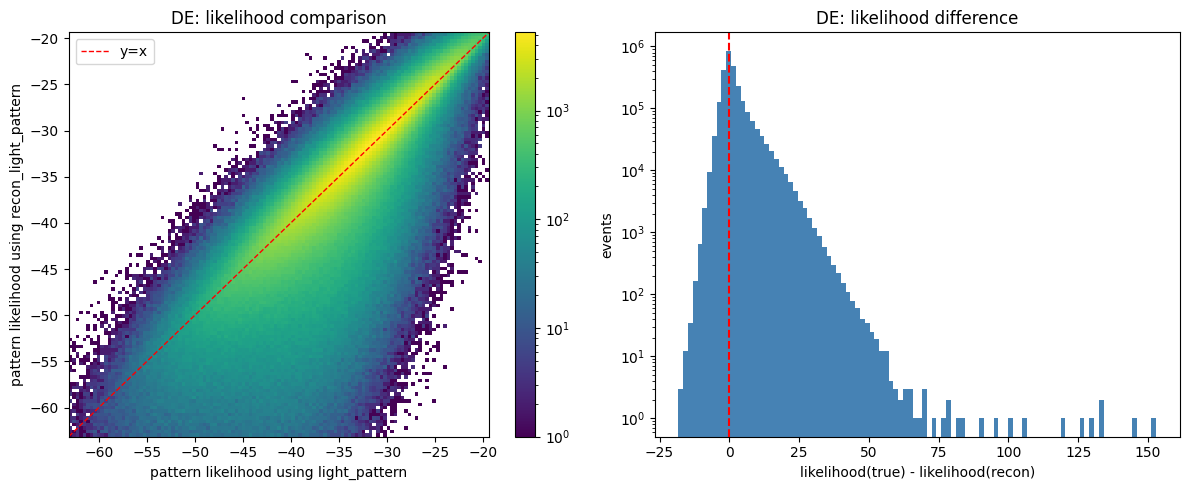

DE: median delta = 0.323, mean delta = 1.600


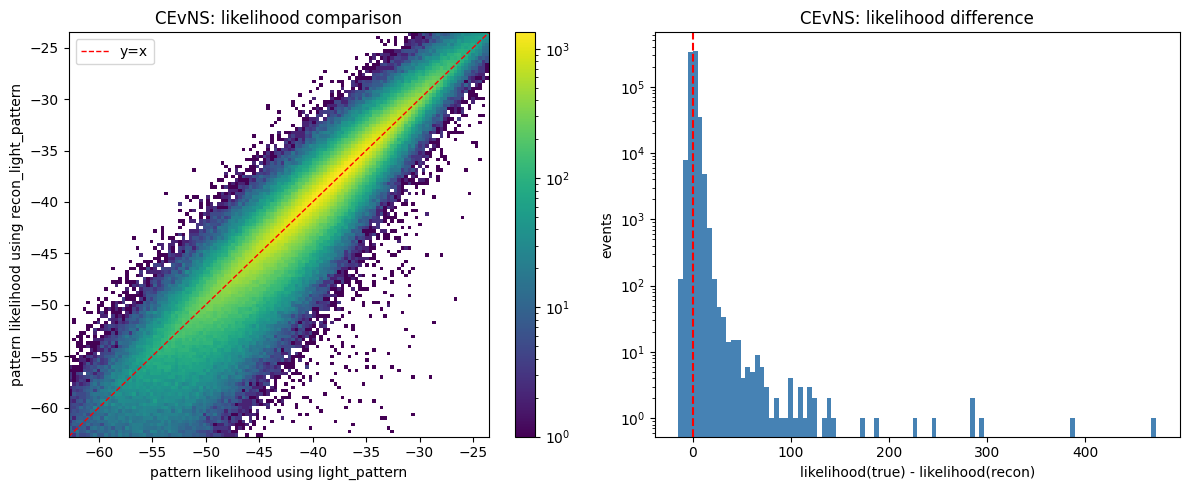

CEvNS: median delta = 0.120, mean delta = 0.467


In [21]:
# ============================================================
# 10.4 pattern likelihood：true light_pattern vs recon_light_pattern
# ============================================================
DE_pattern_true = pattern_likelihood(
    DE_pe_by_area, DE_light_pattern, n_top=N_TOP
)
DE_pattern_recon = pattern_likelihood(
    DE_pe_by_area, DE_recon_light_pattern, n_top=N_TOP
)

CEvNS_pattern_true = pattern_likelihood(
    cevns_pe_by_area, cevns_light_pattern, n_top=N_TOP
)
CEvNS_pattern_recon = pattern_likelihood(
    cevns_pe_by_area, cevns_recon_light_pattern, n_top=N_TOP
)

# 验证 recon likelihood 与前面 cell 的 pattern / cevns_pattern 一致
print("DE   allclose(pattern, DE_pattern_recon):",
      np.allclose(pattern, DE_pattern_recon, equal_nan=True))
print("CEvNS allclose(cevns_pattern, CEvNS_pattern_recon):",
      np.allclose(cevns_pattern, CEvNS_pattern_recon, equal_nan=True))

likelihood_datasets = [
    ("DE", DE_pattern_true, DE_pattern_recon),
    ("CEvNS", CEvNS_pattern_true, CEvNS_pattern_recon),
]

for name, true_ll, recon_ll in likelihood_datasets:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    lo = np.nanpercentile(
        np.concatenate([true_ll, recon_ll]), 0.5
    )
    hi = np.nanpercentile(
        np.concatenate([true_ll, recon_ll]), 99.5
    )

    ax = axes[0]
    h = ax.hist2d(
        true_ll,
        recon_ll,
        bins=(np.linspace(lo, hi, 120), np.linspace(lo, hi, 120)),
        cmap="viridis",
        norm=LogNorm(),
    )
    ax.plot([lo, hi], [lo, hi], "r--", lw=1, label="y=x")
    ax.set_xlabel("pattern likelihood using light_pattern")
    ax.set_ylabel("pattern likelihood using recon_light_pattern")
    ax.set_title(f"{name}: likelihood comparison")
    ax.legend()
    plt.colorbar(h[3], ax=ax)

    delta = true_ll - recon_ll
    ax = axes[1]
    ax.hist(delta[~np.isnan(delta)], bins=100, color="steelblue")
    ax.axvline(0, color="red", linestyle="--")
    ax.set_xlabel("likelihood(true) - likelihood(recon)")
    ax.set_ylabel("events")
    ax.set_yscale("log")
    ax.set_title(f"{name}: likelihood difference")

    plt.tight_layout()
    #plt.savefig(ANALYSIS_DIR / f"{name}_pattern_likelihood_comparison.png", dpi=150)
    plt.show()

    print(
        f"{name}: median delta = {np.nanmedian(delta):.3f}, "
        f"mean delta = {np.nanmean(delta):.3f}"
    )


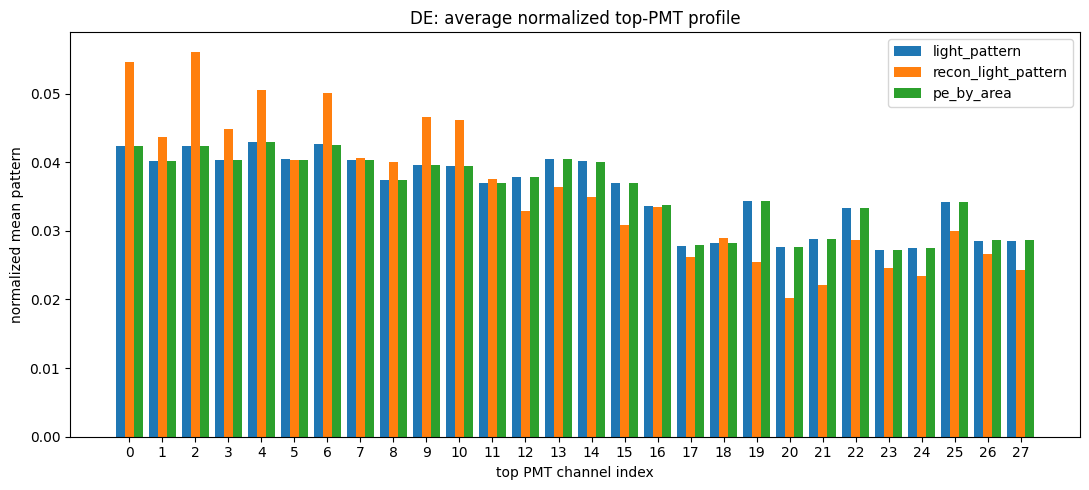

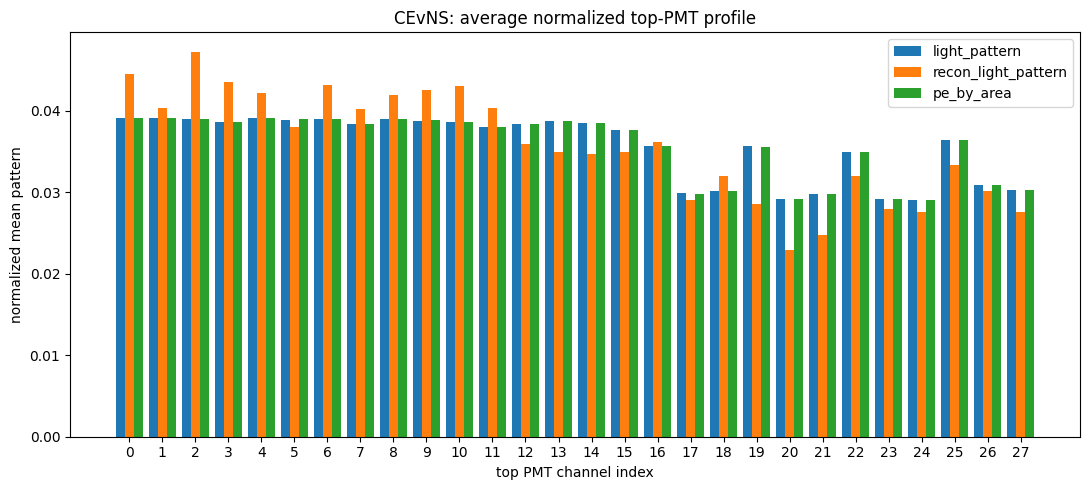

In [22]:
# ============================================================
# 10.5 平均归一化 top-PMT 光斑剖面
# ============================================================
def normalized_mean_profile(pattern, n_top=N_TOP):
    """把每个事件归一化到总光量为 1 后，对事件平均。"""
    top = pattern[:, :n_top]
    total = np.nansum(top, axis=1, keepdims=True)
    normed = top / np.clip(total, 1e-12, None)
    return np.nanmean(normed, axis=0)


profile_datasets = [
    (
        "DE",
        DE_light_pattern,
        DE_recon_light_pattern,
        DE_pe_by_area,
    ),
    (
        "CEvNS",
        cevns_light_pattern,
        cevns_recon_light_pattern,
        cevns_pe_by_area,
    ),
]

for name, light, recon, observed in profile_datasets:
    p_light = normalized_mean_profile(light)
    p_recon = normalized_mean_profile(recon)
    p_obs = normalized_mean_profile(observed)

    x = np.arange(N_TOP)
    width = 0.27
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(x - width, p_light, width=width, label="light_pattern")
    ax.bar(x, p_recon, width=width, label="recon_light_pattern")
    ax.bar(x + width, p_obs, width=width, label="pe_by_area")
    ax.set_xticks(x)
    ax.set_xlabel("top PMT channel index")
    ax.set_ylabel("normalized mean pattern")
    ax.set_title(f"{name}: average normalized top-PMT profile")
    ax.legend()
    plt.tight_layout()
    #plt.savefig(ANALYSIS_DIR / f"{name}_mean_pattern_profile.png", dpi=150)
    plt.show()


DE example index: 292264


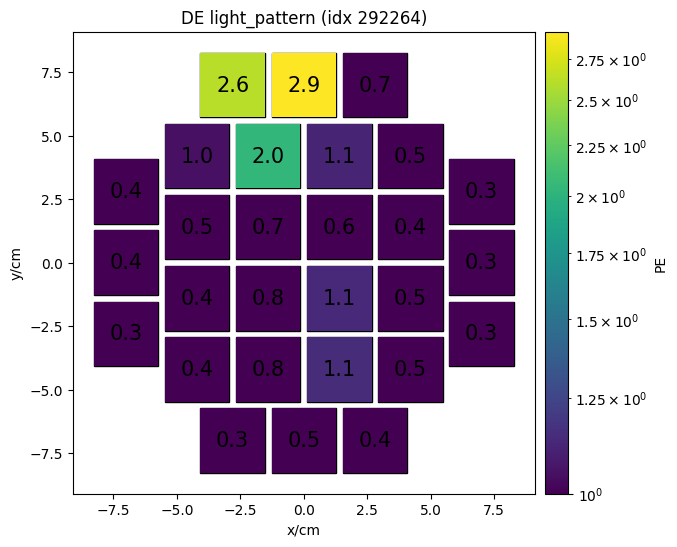

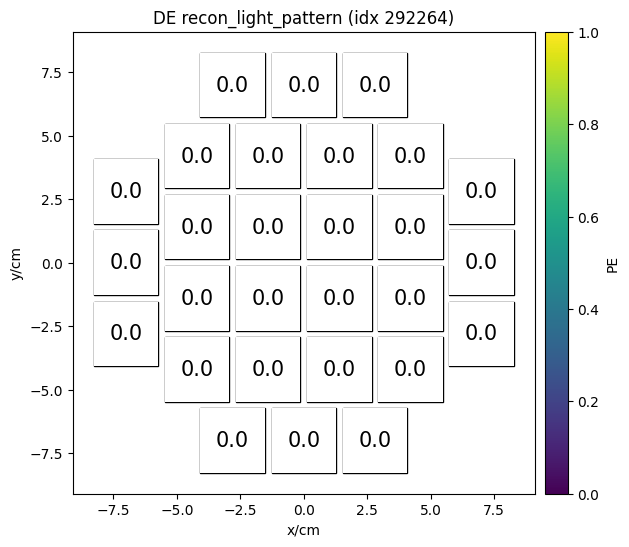

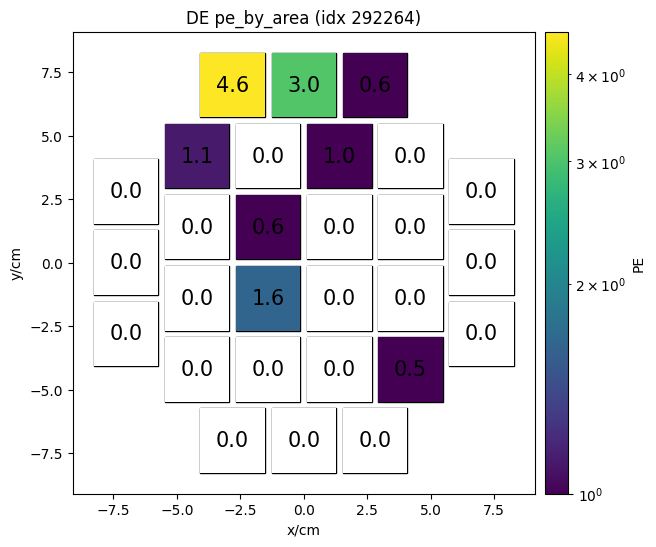

CEvNS example index: 161687


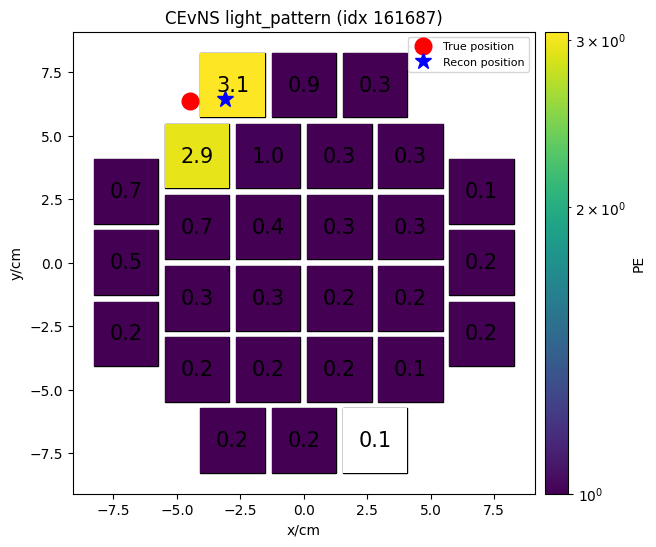

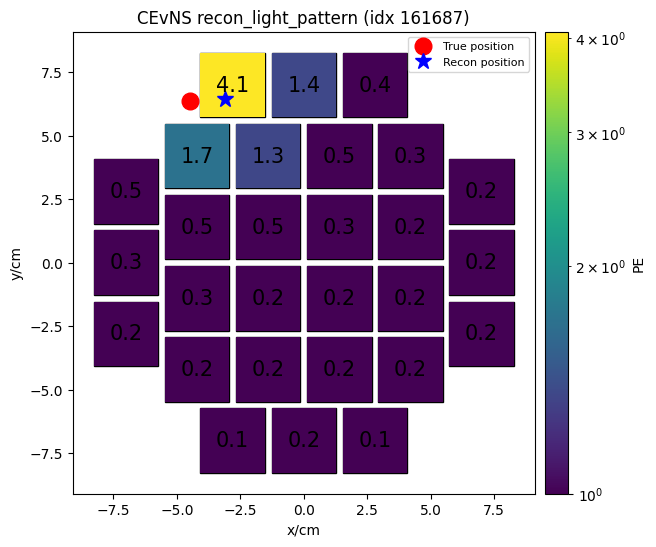

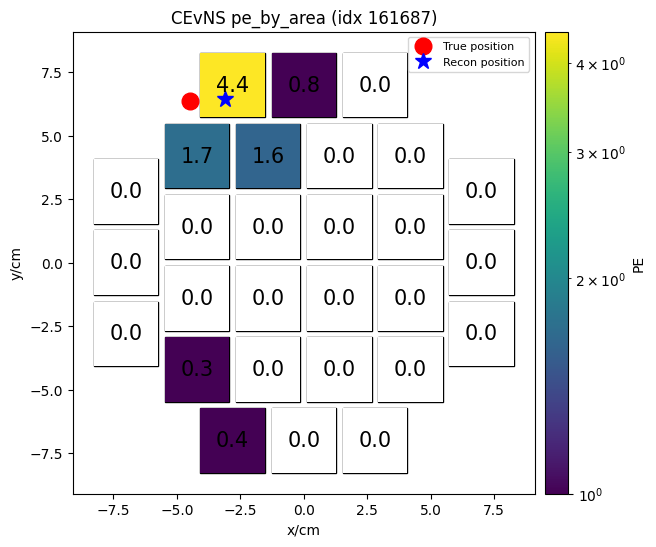

In [23]:
# ============================================================
# 10.6 典型事件光斑：light / recon / observed 对比
# ============================================================
# DE：取 recon likelihood 最高的事件
if len(DE_pattern_recon):
    idx_de = int(np.nanargmax(DE_pattern_recon))
    print("DE example index:", idx_de)
    pattern_plot(
        DE_light_pattern[idx_de],
        pmt_info=pipe.pmt_top,
        title=f"DE light_pattern (idx {idx_de})",
    )
    pattern_plot(
        DE_recon_light_pattern[idx_de],
        pmt_info=pipe.pmt_top,
        title=f"DE recon_light_pattern (idx {idx_de})",
    )
    pattern_plot(
        DE_pe_by_area[idx_de],
        pmt_info=pipe.pmt_top,
        title=f"DE pe_by_area (idx {idx_de})",
    )

# CEvNS：取 recon likelihood 最高的事件，并叠加真值/重建位置
if len(CEvNS_pattern_recon):
    idx_cevns = int(np.nanargmax(CEvNS_pattern_recon))
    print("CEvNS example index:", idx_cevns)
    pattern_plot(
        cevns_light_pattern[idx_cevns],
        electron=arr["pos_original"][idx_cevns],
        pos_recons=arr["pos_recon"][idx_cevns],
        pmt_info=pipe.pmt_top,
        title=f"CEvNS light_pattern (idx {idx_cevns})",
    )
    pattern_plot(
        cevns_recon_light_pattern[idx_cevns],
        electron=arr["pos_original"][idx_cevns],
        pos_recons=arr["pos_recon"][idx_cevns],
        pmt_info=pipe.pmt_top,
        title=f"CEvNS recon_light_pattern (idx {idx_cevns})",
    )
    pattern_plot(
        cevns_pe_by_area[idx_cevns],
        electron=arr["pos_original"][idx_cevns],
        pos_recons=arr["pos_recon"][idx_cevns],
        pmt_info=pipe.pmt_top,
        title=f"CEvNS pe_by_area (idx {idx_cevns})",
    )


## 11) 每个 `pile_up_order` 的 DE 平均面积分析

`pipe.pile_up_results` 按 `pipe.pile_up_orders` 排列，每个 order 对应一种延迟电子
pile-up 多重数。这里直接对每个 order 内所有存活事件计算
`area = sum(pe_by_area, axis=1)`，统计均值、标准差、中位数，并比较不同 order。


In [24]:
# ============================================================
# 11.1 计算并核对每个 pile_up_order 的面积
# ============================================================
DE_area_by_order = [
    np.sum(res.pe_by_area, axis=1)
    for res in pipe.pile_up_results
]

if DE_area_by_order:
    DE_area_from_orders = np.concatenate(DE_area_by_order)
    print("各 order 面积拼接后与已有 DE_area 是否一致:",
          np.allclose(DE_area_from_orders, DE_area))

print()
print(
    f"{'order':>6} {'count':>8} {'mean':>12} {'std':>12} "
    f"{'median':>12} {'min':>12} {'max':>12}"
)
for order, areas in zip(pipe.pile_up_orders, DE_area_by_order):
    if len(areas) == 0:
        print(
            f"{order:>6} {0:>8} {'--':>12} {'--':>12} "
            f"{'--':>12} {'--':>12} {'--':>12}"
        )
        continue
    print(
        f"{order:>6} {len(areas):>8} {np.mean(areas):>12.3f} "
        f"{np.std(areas):>12.3f} {np.median(areas):>12.3f} "
        f"{np.min(areas):>12.3f} {np.max(areas):>12.3f}"
    )


各 order 面积拼接后与已有 DE_area 是否一致: True

 order    count         mean          std       median          min          max
     2  2134339       60.494       14.196       59.923       30.000      145.939
     3   370851       89.840       18.743       89.785       30.008      192.547
     4    97941      120.152       22.164      120.340       30.029      228.046
     5    33278      150.805       25.116      150.997       30.140      251.342
     6    13637      181.454       27.384      181.883       30.633      281.627
     7     6329      211.444       30.226      212.341       41.553      298.818


/tmp/ipykernel_2200553/3524700270.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(nonempty_areas, labels=[str(o) for o in nonempty_orders], showfliers=False)


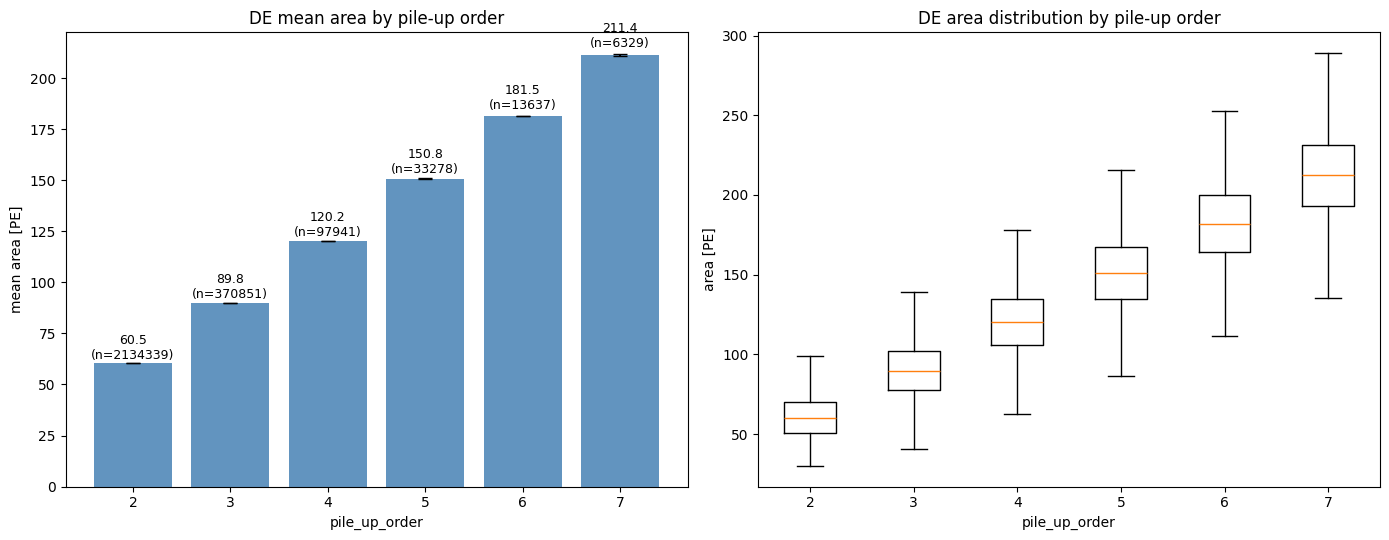

In [25]:
# ============================================================
# 11.2 各 order 平均面积条形图与面积分布箱线图
# ============================================================
orders = pipe.pile_up_orders
order_counts = np.array([len(areas) for areas in DE_area_by_order])
order_means = np.array(
    [np.mean(areas) if len(areas) else np.nan for areas in DE_area_by_order]
)
order_stds = np.array(
    [np.std(areas) if len(areas) else np.nan for areas in DE_area_by_order]
)
order_sems = order_stds / np.sqrt(np.maximum(order_counts, 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
bars = ax.bar(
    orders,
    order_means,
    yerr=order_sems,
    capsize=5,
    color="steelblue",
    alpha=0.85,
)
ax.set_xlabel("pile_up_order")
ax.set_ylabel("mean area [PE]")
ax.set_title("DE mean area by pile-up order")
ax.set_xticks(orders)
for bar, mean_val, count in zip(bars, order_means, order_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f"{mean_val:.1f}\n(n={int(count)})",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax = axes[1]
nonempty_areas = [areas for areas in DE_area_by_order if len(areas) > 0]
nonempty_orders = [o for o, a in zip(orders, DE_area_by_order) if len(a) > 0]
ax.boxplot(nonempty_areas, labels=[str(o) for o in nonempty_orders], showfliers=False)
ax.set_xlabel("pile_up_order")
ax.set_ylabel("area [PE]")
ax.set_title("DE area distribution by pile-up order")

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "DE_area_by_pile_up_order.png", dpi=150)
plt.show()


 order    count    mean_area  mean_area/order
     2  2134339       60.494           30.247
     3   370851       89.840           29.947
     4    97941      120.152           30.038
     5    33278      150.805           30.161
     6    13637      181.454           30.242
     7     6329      211.444           30.206


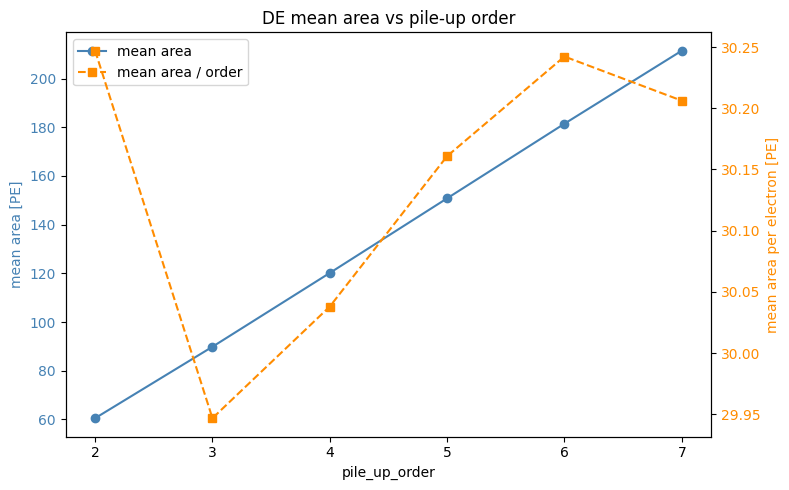

已保存 DE_area_by_order.json


In [26]:
# ============================================================
# 11.3 平均面积与单位电子平均面积随 order 的变化
# ============================================================
mean_area_by_order = order_means.copy()
mean_area_per_electron = np.divide(
    mean_area_by_order,
    np.array(orders, dtype=float),
    out=np.full_like(mean_area_by_order, np.nan),
    where=np.array(orders, dtype=float) != 0,
)

print(
    f"{'order':>6} {'count':>8} {'mean_area':>12} "
    f"{'mean_area/order':>16}"
)
for order, count, mean_area, mean_per_e in zip(
    orders, order_counts, mean_area_by_order, mean_area_per_electron
):
    print(
        f"{order:>6} {int(count):>8} {mean_area:>12.3f} "
        f"{mean_per_e:>16.3f}"
    )

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(orders, mean_area_by_order, "o-", color="steelblue", label="mean area")
ax1.set_xlabel("pile_up_order")
ax1.set_ylabel("mean area [PE]", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(
    orders,
    mean_area_per_electron,
    "s--",
    color="darkorange",
    label="mean area / order",
)
ax2.set_ylabel("mean area per electron [PE]", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
ax1.set_title("DE mean area vs pile-up order")
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "DE_mean_area_vs_order.png", dpi=150)
plt.show()

# 保存每 order 的面积统计
area_summary = []
for order, areas in zip(orders, DE_area_by_order):
    area_summary.append(
        {
            "order": int(order),
            "count": int(len(areas)),
            "mean_area": float(np.mean(areas)) if len(areas) else None,
            "std_area": float(np.std(areas)) if len(areas) else None,
            "median_area": float(np.median(areas)) if len(areas) else None,
            "min_area": float(np.min(areas)) if len(areas) else None,
            "max_area": float(np.max(areas)) if len(areas) else None,
            "mean_area_per_electron": float(
                np.mean(areas) / order
            ) if len(areas) else None,
        }
    )

with open(ANALYSIS_DIR / "DE_area_by_order.json", "w", encoding="utf-8") as f:
    json.dump(area_summary, f, ensure_ascii=False, indent=2)
print("已保存 DE_area_by_order.json")
